** Analyse Exploratoire des Données (EDA)**


In [1]:
from google.colab import files
files.upload()

Saving medical_charges.csv to medical_charges.csv


{'medical_charges.csv': b'age,sex,bmi,children,smoker,region,charges\r\n19,female,27.9,0,yes,southwest,16884.924\r\n18,male,33.77,1,no,southeast,1725.5523\r\n28,male,33,3,no,southeast,4449.462\r\n33,male,22.705,0,no,northwest,21984.47061\r\n32,male,28.88,0,no,northwest,3866.8552\r\n31,female,25.74,0,no,southeast,3756.6216\r\n46,female,33.44,1,no,southeast,8240.5896\r\n37,female,27.74,3,no,northwest,7281.5056\r\n37,male,29.83,2,no,northeast,6406.4107\r\n60,female,25.84,0,no,northwest,28923.13692\r\n25,male,26.22,0,no,northeast,2721.3208\r\n62,female,26.29,0,yes,southeast,27808.7251\r\n23,male,34.4,0,no,southwest,1826.843\r\n56,female,39.82,0,no,southeast,11090.7178\r\n27,male,42.13,0,yes,southeast,39611.7577\r\n19,male,24.6,1,no,southwest,1837.237\r\n52,female,30.78,1,no,northeast,10797.3362\r\n23,male,23.845,0,no,northeast,2395.17155\r\n56,male,40.3,0,no,southwest,10602.385\r\n30,male,35.3,0,yes,southwest,36837.467\r\n60,female,36.005,0,no,northeast,13228.84695\r\n30,female,32.4,1,no,s

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, shapiro

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm


plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")
sns.set_palette("husl")

import warnings
warnings.filterwarnings('ignore')



print("\n" + "-"*70)
print("1. CHARGEMENT DES DONNÉES ET STATISTIQUES DESCRIPTIVES")
print("-"*70)
df = pd.read_csv("medical_charges.csv") # Charger dataset


print(f"Dimensions du dataset : {df.shape}")
print(f"Nombre total d'observations (lignes) : {df.shape[0]:,}")
print(f"Nombre total de variables (colonnes) : {df.shape[1]}" ,"\n")




----------------------------------------------------------------------
1. CHARGEMENT DES DONNÉES ET STATISTIQUES DESCRIPTIVES
----------------------------------------------------------------------
Dimensions du dataset : (1338, 7)
Nombre total d'observations (lignes) : 1,338
Nombre total de variables (colonnes) : 7 



In [3]:
# Statistiques descriptives générales

print("\nSTATISTIQUES DESCRIPTIVES - Générales:")
print("-"*38)
print(df.info())

print("\nSTATISTIQUES DESCRIPTIVES - Variables Numériques:")
print("-"*49)
print(df.describe())


STATISTIQUES DESCRIPTIVES - Générales:
--------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

STATISTIQUES DESCRIPTIVES - Variables Numériques:
-------------------------------------------------
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900


In [4]:
print("\nAPERÇU DU DATASET - Premières lignes")
print("-"*37)
print(df.head())

print("\nAPERÇU DU DATASET - Dernières lignes")
print("-"*37)
print(df.tail())


APERÇU DU DATASET - Premières lignes
-------------------------------------
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

APERÇU DU DATASET - Dernières lignes
-------------------------------------
      age     sex    bmi  children smoker     region     charges
1333   50    male  30.97         3     no  northwest  10600.5483
1334   18  female  31.92         0     no  northeast   2205.9808
1335   18  female  36.85         0     no  southeast   1629.8335
1336   21  female  25.80         0     no  southwest   2007.9450
1337   61  female  29.07         0    yes  northwest  29141.3603


In [ ]:
print("\nTYPES DES VARIABLES ")
print("-"*19)
df.dtypes


TYPES DES VARIABLES 
-------------------


,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


**L'analyse univariée_1 Varible :** Permet d'étudier la distribution de chaque variable individuellement afin de détecter d'éventuelles anomalies(outliers) et comprendre leur comportement.


----------------------------------------------------------------------
Analyse univariée - DISTRIBUTION DES VARIABLES NUMÉRIQUES
----------------------------------------------------------------------

DISTRIBUTION DE LA VARIABLE CIBLE (charges):
-------------------------------------------
  Skewness: 1.5142
  Kurtosis: 1.5958


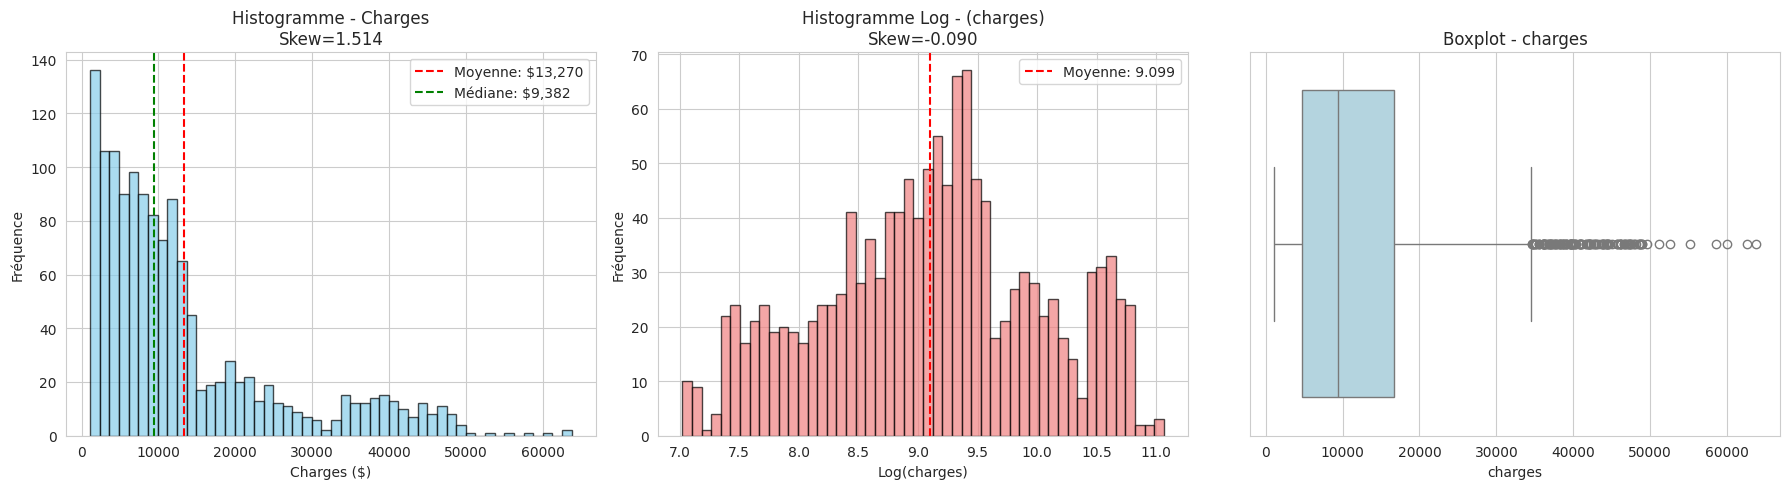


ANALYSE DES VARIABLES NUMÉRIQUES _ age bmi children:
----------------------------------------------------
   Variable  Skewness  Kurtosis Interprétation_Skew
0       age  0.055610 -1.244921  Presque symétrique
1       bmi  0.283729 -0.055023  Presque symétrique
2  children  0.937328  0.197217  Presque symétrique
3   charges  1.514180  1.595821  Asymétrique droite


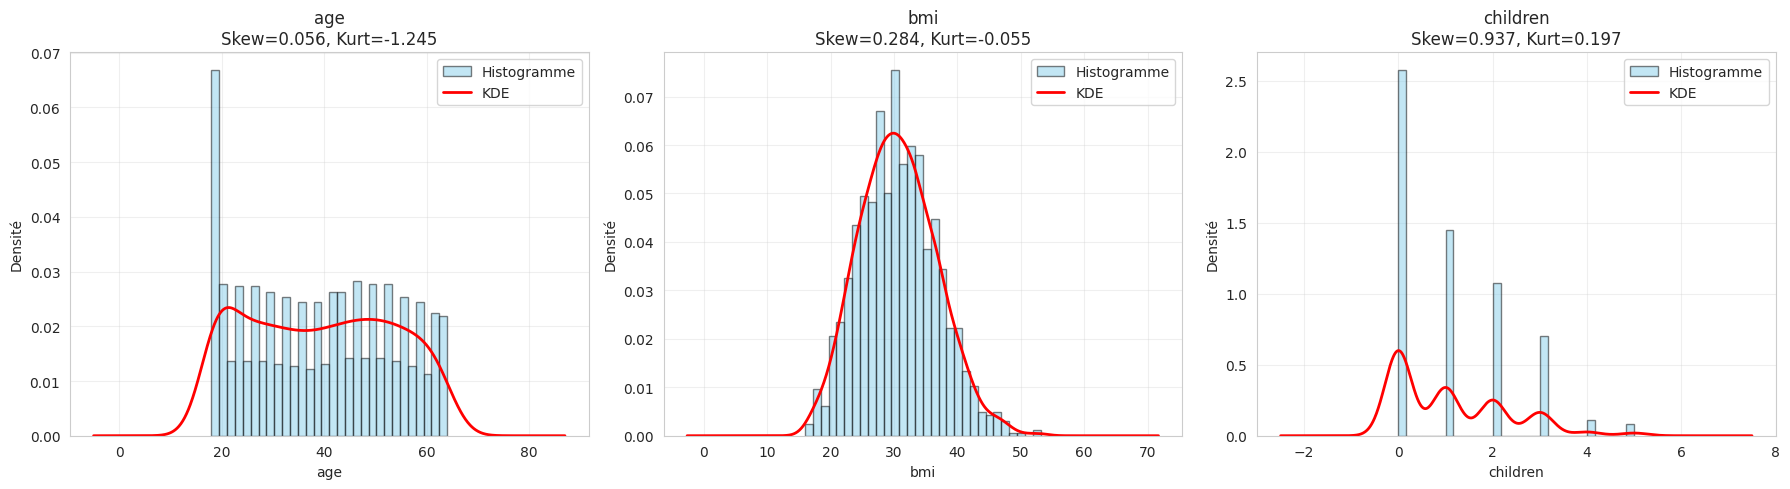

In [5]:
print("\n" + "-"*70)
print("Analyse univariée - DISTRIBUTION DES VARIABLES NUMÉRIQUES")
print("-"*70)


# Analyse de la variable cible
print("\nDISTRIBUTION DE LA VARIABLE CIBLE (charges):")
print("-"*43)
print(f"  Skewness: {skew(df['charges']):.4f}")
print(f"  Kurtosis: {kurtosis(df['charges']):.4f}")

# Visualisation de charges
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogramme
axes[0].hist(df['charges'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(df['charges'].mean(), color='red', linestyle='--',
                label=f'Moyenne: ${df["charges"].mean():,.0f}')
axes[0].axvline(df['charges'].median(), color='green', linestyle='--',
                label=f'Médiane: ${df["charges"].median():,.0f}')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title(f'Histogramme - Charges\nSkew={skew(df["charges"]):.3f}')
axes[0].legend()


# Distribution log-normale
log_charges = np.log(df['charges'])
axes[1].hist(log_charges, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1].axvline(log_charges.mean(), color='red', linestyle='--',
                label=f'Moyenne: {log_charges.mean():.3f}')
axes[1].set_xlabel('Log(charges)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title(f'Histogramme Log - (charges)\nSkew={skew(log_charges):.3f}')
axes[1].legend()


# Boxplot

sns.boxplot(x=df['charges'], ax=axes[2], color='lightblue')
axes[2].set_title('Boxplot - charges')

plt.tight_layout()
plt.show()


# Analyse des variables numériques _ age bmi children
print("\nANALYSE DES VARIABLES NUMÉRIQUES _ age bmi children:")
print("-"*52)
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

skewness_data = []
for col in numeric_features:
   if col in df.columns:
        skew_val = skew(df[col])
        kurt_val = kurtosis(df[col])
        skewness_data.append({
            'Variable': col,
            'Skewness': skew_val,
            'Kurtosis': kurt_val,
            'Interprétation_Skew': 'Asymétrique droite' if skew_val > 1
                                   else 'Asymétrique gauche' if skew_val < -1
                                   else 'Presque symétrique'
        })

skewness_df = pd.DataFrame(skewness_data)
print(skewness_df)

# Visualisation des distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.ravel()

for i, col in enumerate(numeric_features):
    if col in df.columns and i < len(axes):
        # Histogramme + KDE
        axes[i].hist(df[col], bins=30, alpha=0.5, color='skyblue',
                    edgecolor='black', density=True, label='Histogramme')
        df[col].plot(kind='density', ax=axes[i], color='red',
                    linewidth=2, label='KDE')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Densité')
        axes[i].set_title(f'{col}\nSkew={skew(df[col]):.3f}, Kurt={kurtosis(df[col]):.3f}')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




----------------------------------------------------------------------
Analyse univariée - DISTRIBUTION DES VARIABLES CATÉGORIQUES
----------------------------------------------------------------------


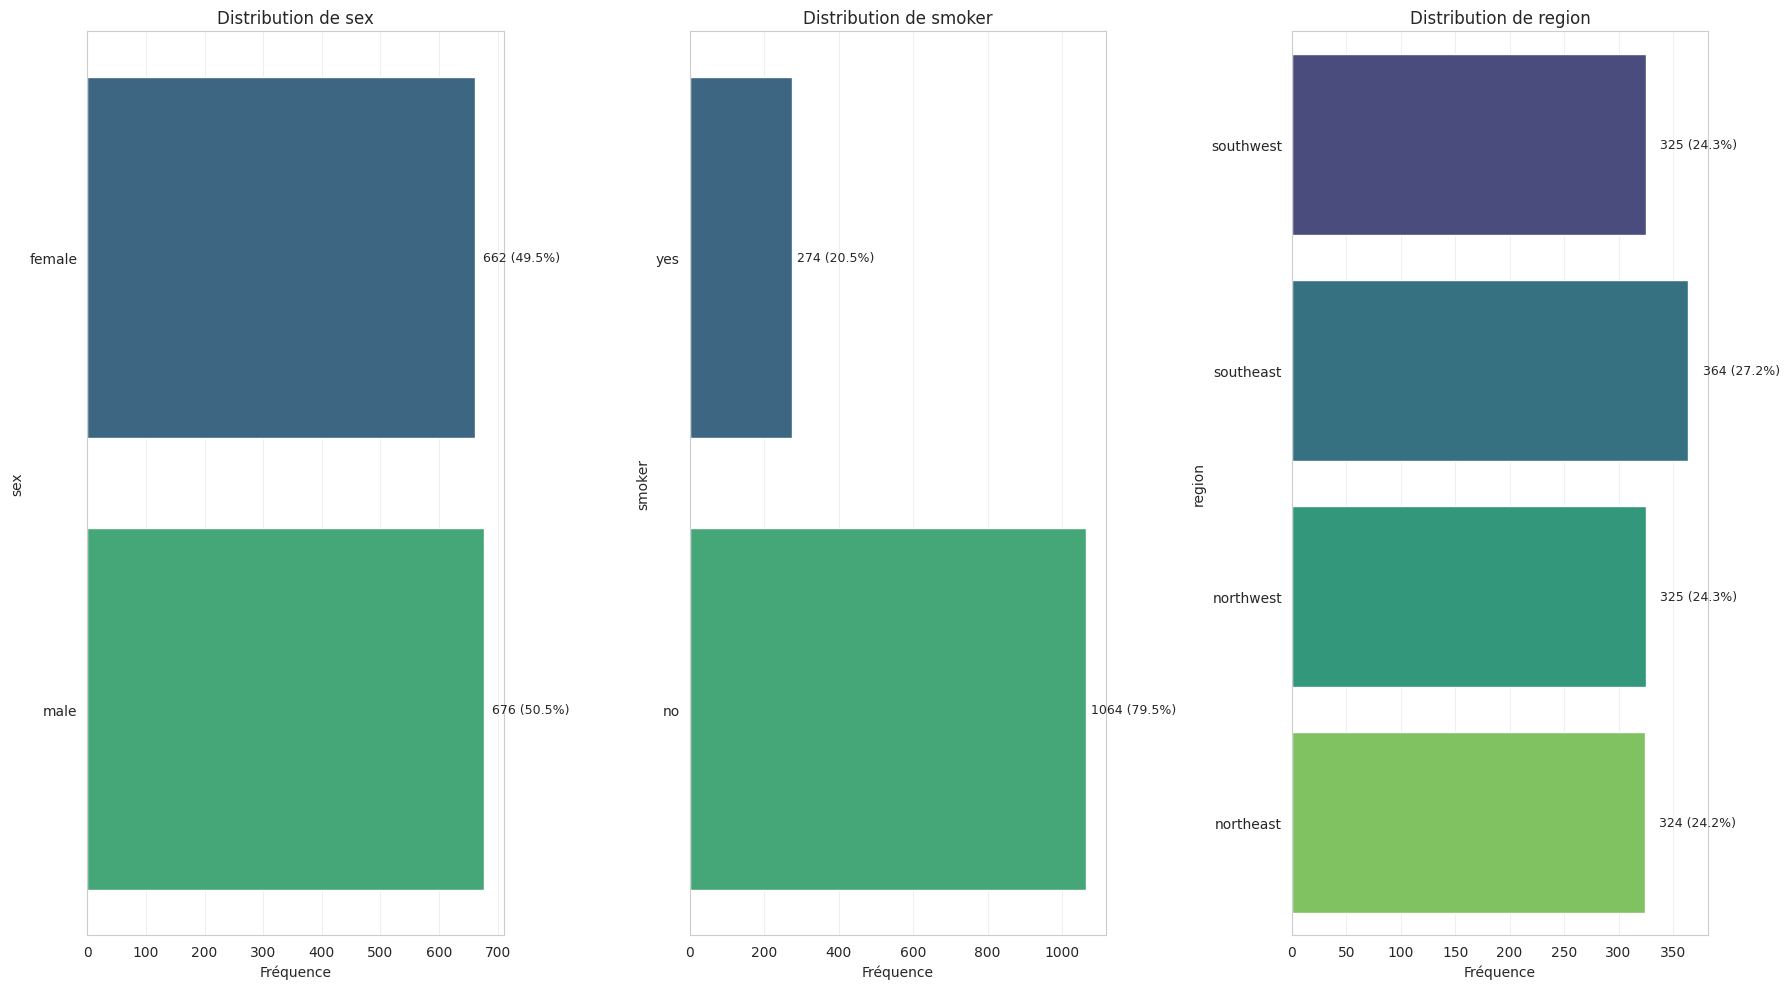


STATISTIQUES DES VARIABLES CATÉGORIQUES:
----------------------------------------
  Variable  Nb_Catégories Catégorie_Dominante  Fréq_Dominante Pct_Dominante
2   region              4           southeast             364         27.2%
0      sex              2                male             676         50.5%
1   smoker              2                  no            1064         79.5%


In [6]:
# Variable catégorielles : Comptage des modalités
# Configuration des graphiques


print("\n" + "-"*70)
print("Analyse univariée - DISTRIBUTION DES VARIABLES CATÉGORIQUES")
print("-"*70)

categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Barres horizontales pour les variables catégoriques
fig, axes = plt.subplots(1, 3, figsize=(18, 10))

for i, col in enumerate(categorical_features):
    if col in df.columns and i < len(axes):
        sns.countplot(y=df[col], ax=axes[i], palette='viridis')

        axes[i].set_xlabel('Fréquence')
        axes[i].set_title(f'Distribution de {col}')
        axes[i].grid(axis='x', alpha=0.3)


        # Ajouter les valeurs
        total = len(df)
        for p in axes[i].patches:
            width = p.get_width()
            axes[i].text(width + total*0.01,
                         p.get_y() + p.get_height()/2,
                         f'{int(width)} ({width/total*100:.1f}%)',
                         va='center', fontsize=9)

plt.tight_layout()
plt.show()


# Statistiques des variables catégoriques

print("\nSTATISTIQUES DES VARIABLES CATÉGORIQUES:")
print("-" * 40)
cat_stats = []
for col in categorical_features:
    if col in df.columns:
        cat_stats.append({
            'Variable': col,
            'Nb_Catégories': df[col].nunique(),
            'Catégorie_Dominante': df[col].mode()[0],
            'Fréq_Dominante': df[col].value_counts().iloc[0],
            'Pct_Dominante': f"{(df[col].value_counts().iloc[0]/len(df)*100):.1f}%"
        })

cat_stats_df = pd.DataFrame(cat_stats).sort_values('Nb_Catégories', ascending=False)
print(cat_stats_df.head(10))



**L'analyse bivariée_2 Variables :** Permet d'étudier la relation texte en grasentre deux variables afin d'identifier les dépendances et les influences possibles sur la variable cible.


----------------------------------------------------------------------
ANALYSE BIVARIÉE - Features vs Target
---------------------------------------------------------------------- 

RELATION VARIABLES NUMÉRIQUES vs CHARGES - SCATTER
-------------------------------------------------- 



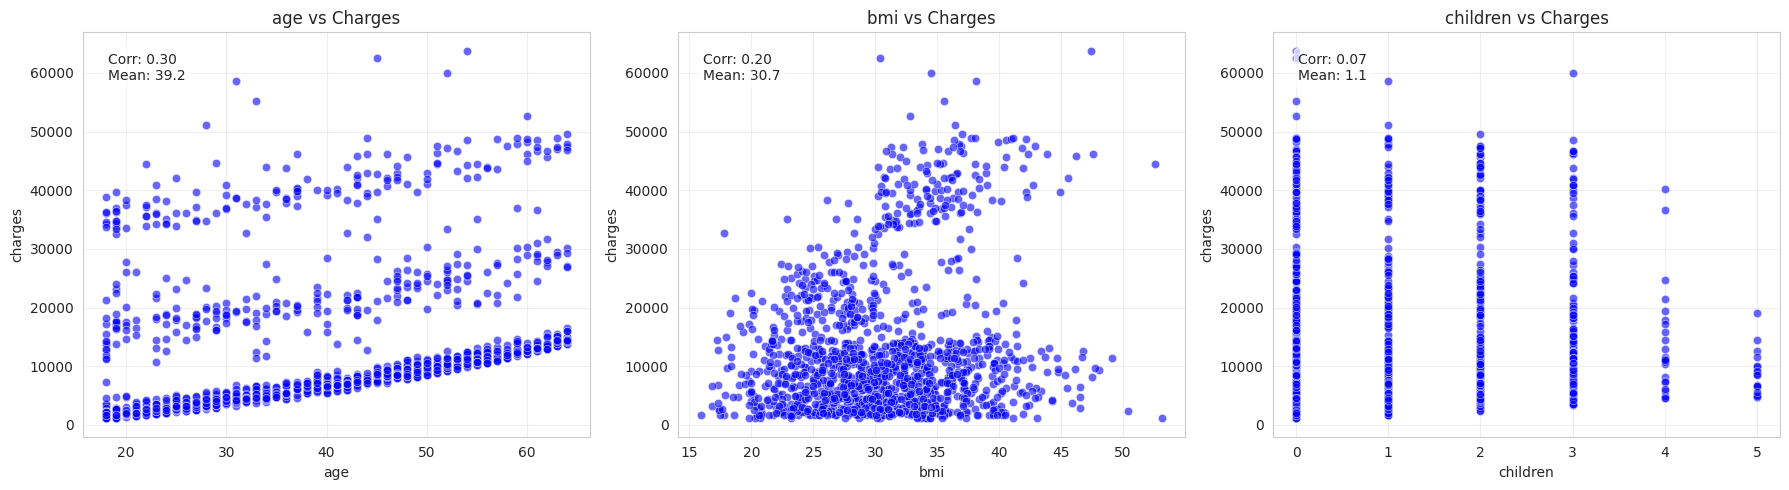


RELATION VARIABLES CATÉGORIELLES vs CHARGES - BOXPLOT 
----------------------------------------------------- 



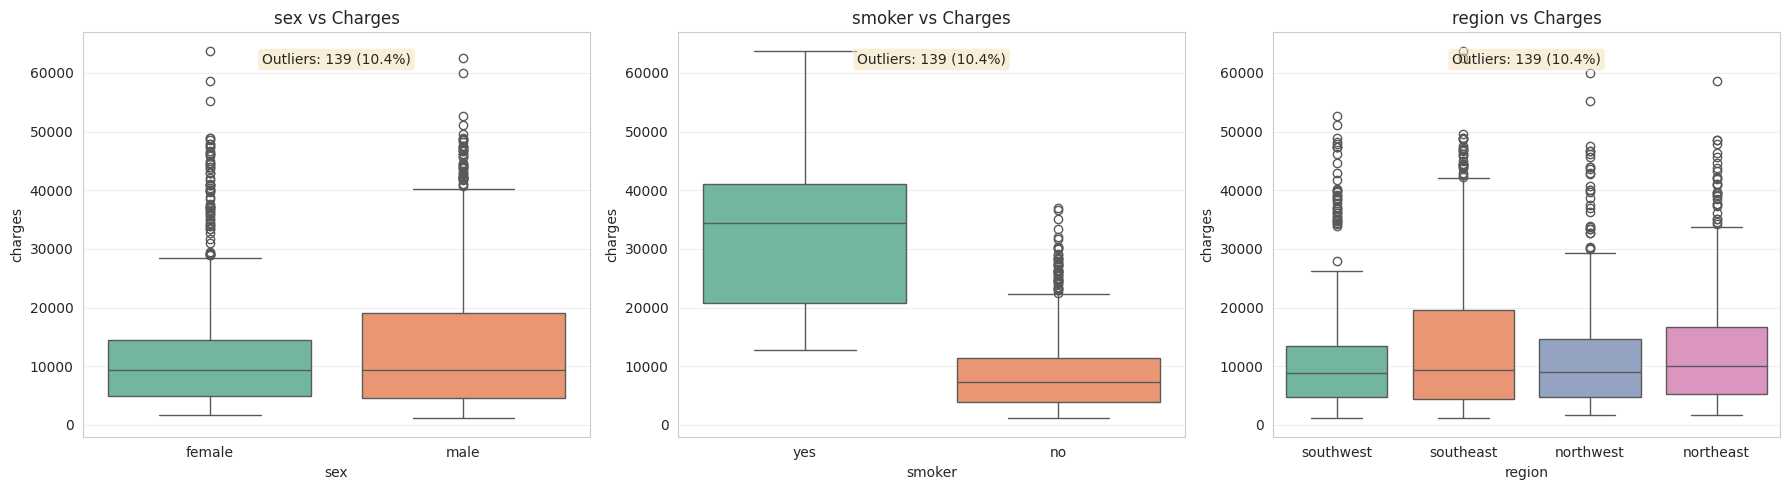

In [7]:
print("\n" + "-"*70)
print("ANALYSE BIVARIÉE - Features vs Target")
print("-"*70,'\n')


print("RELATION VARIABLES NUMÉRIQUES vs CHARGES - SCATTER")
print("-"*50,'\n')

# VARIABLES NUMÉRIQUES - Scatter plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.ravel()

for i, col in enumerate(numeric_features):
 if col in df.columns and i < len(axes):
      sns.scatterplot(x=df[col], y=df['charges'], ax=axes[i], color='blue', alpha=0.6)

      axes[i].set_xlabel(col)
      axes[i].set_ylabel('charges')
      axes[i].set_title(f'{col} vs Charges')
      axes[i].grid(alpha=0.3)

      # Corrélation
      corr = df[col].corr(df['charges'])

      # Moyenne
      mean_val = df[col].mean()

      axes[i].text(0.05, 0.95,
             f'Corr: {corr:.2f}\nMean: {mean_val:.1f}',
             transform=axes[i].transAxes,
             ha='left', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))



plt.tight_layout()
plt.show()

# ANALYSE BIVARIÉE - VARIABLES CATÉGORIELLES vs CHARGES

print("\nRELATION VARIABLES CATÉGORIELLES vs CHARGES - BOXPLOT ")
print("-"*53,'\n')

# RELATION VARIABLES CATÉGORIELLES - Boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # Subplots

if len(categorical_features) == 1:
    axes = [axes]
else:
    axes = axes.ravel()

for i, col in enumerate(categorical_features):
    if col in df.columns:

        sns.boxplot(x=df[col], y=df['charges'], ax=axes[i], palette='Set2')

        axes[i].set_xlabel(col)
        axes[i].set_ylabel('charges')
        axes[i].set_title(f'{col} vs Charges')
        axes[i].grid(axis='y', alpha=0.3)

        # Calcul sur charges (pas col)
        Q1 = df['charges'].quantile(0.25)
        Q3 = df['charges'].quantile(0.75)
        IQR = Q3 - Q1

        outliers = df[(df['charges'] < Q1 - 1.5*IQR) | (df['charges'] > Q3 + 1.5*IQR)]
        axes[i].text(0.5, 0.95, f'Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)',
             transform=axes[i].transAxes, ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()




RELATION BMI VS SMOKER SUR CHARGES - SCATTER
-------------------------------------------- 



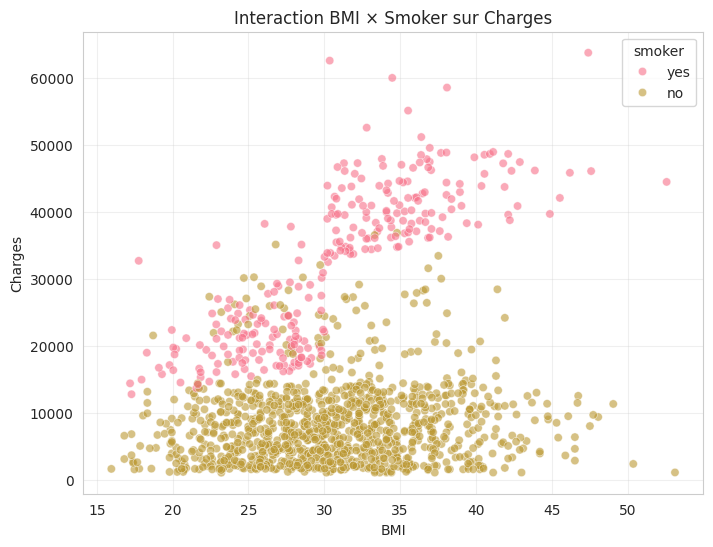

Les fumeurs ont des charges plus élevées, surtout lorsque le BMI est élevé, tandis que l'effet du BMI reste faible chez les non-fumeurs.


In [8]:

print("RELATION BMI VS SMOKER SUR CHARGES - SCATTER")
print("-"*44,'\n')

plt.figure(figsize=(8,6))

sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.6)

plt.title('Interaction BMI × Smoker sur Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.grid(alpha=0.3)

plt.show()

print("Les fumeurs ont des charges plus élevées, surtout lorsque le BMI est élevé, tandis que l'effet du BMI reste faible chez les non-fumeurs.")



**L'analyse multivariée_ 3+ Variables :**  Permet d'examiner les interactions entre plusieurs variables simultanément afin de mieux comprendre leur influence combinée sur la variable cible.


----------------------------------------------------------------------
ANALYSE MULTIVARIÉE
---------------------------------------------------------------------- 

MATRICE DE CORRÉLATION ENTRE VARIABLES NUMÉRIQUES
------------------------------------------------- 



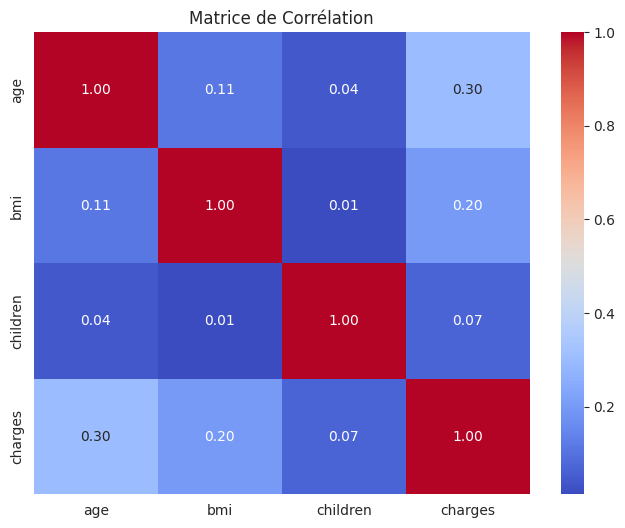


PAIRPLOT DES VARIABLES NUMÉRIQUES COLORÉ PAR 'smoker'
---------------------------------------------------- 



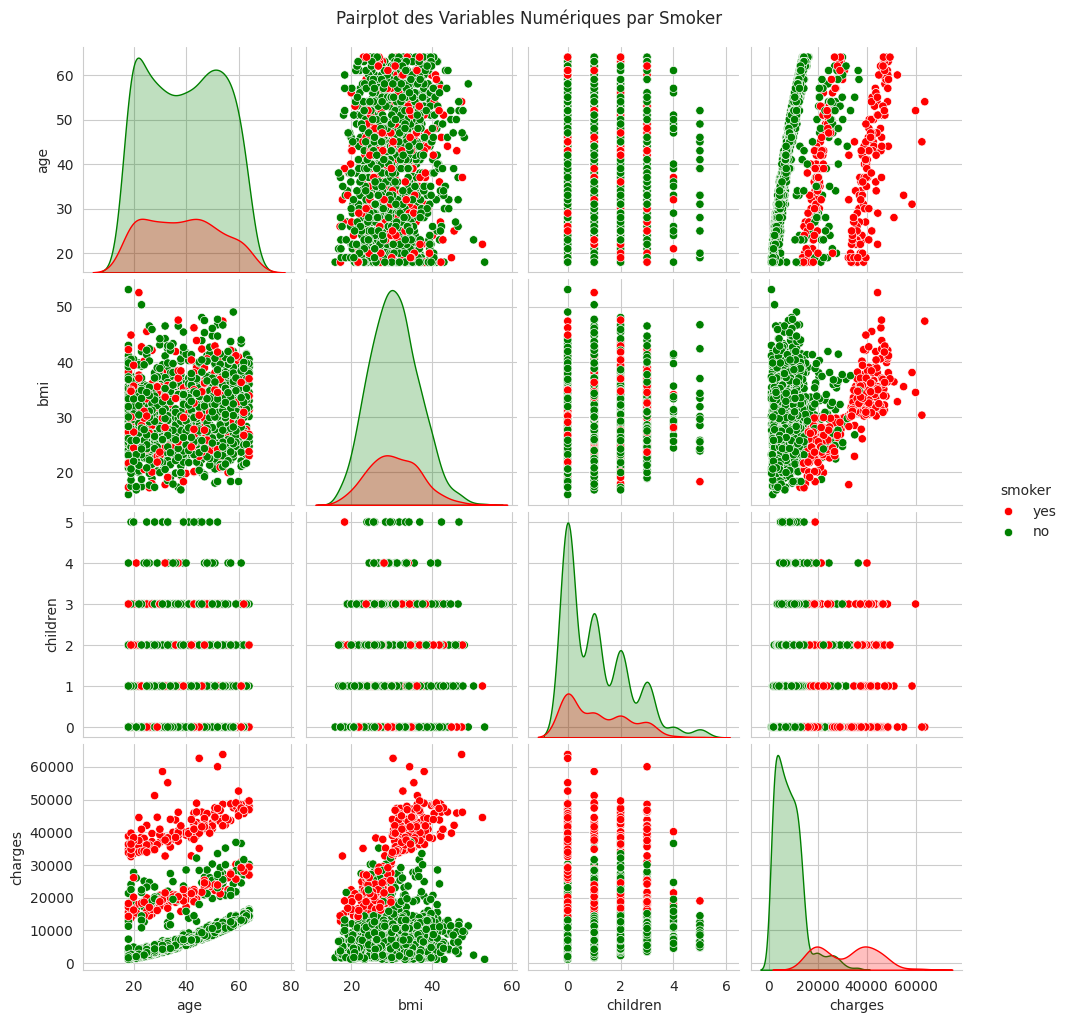

In [9]:

print("\n" + "-"*70)
print("ANALYSE MULTIVARIÉE")
print("-"*70,'\n')

# 1MATRICE DE CORRÉLATION - Heatmap
print("MATRICE DE CORRÉLATION ENTRE VARIABLES NUMÉRIQUES")
print("-"*49,'\n')

# Calcul corrélation (Var numériques)
corr_matrix = df[numeric_features ].corr()

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matrice de Corrélation")
plt.show()

# PAIRPLOT COLORÉ PAR SMOKER
print("\nPAIRPLOT DES VARIABLES NUMÉRIQUES COLORÉ PAR 'smoker'")
print("-"*52,'\n')

# pairplot coloré par smoker
sns.pairplot(df[numeric_features + ['smoker']], hue='smoker', palette={'yes':'red','no':'green'}, diag_kind='kde')
plt.suptitle("Pairplot des Variables Numériques par Smoker", y=1.02)
plt.show()


----------------------------------------------------------------------
DÉTECTION DES OUTLIERS - MÉTHODE IQR
----------------------------------------------------------------------


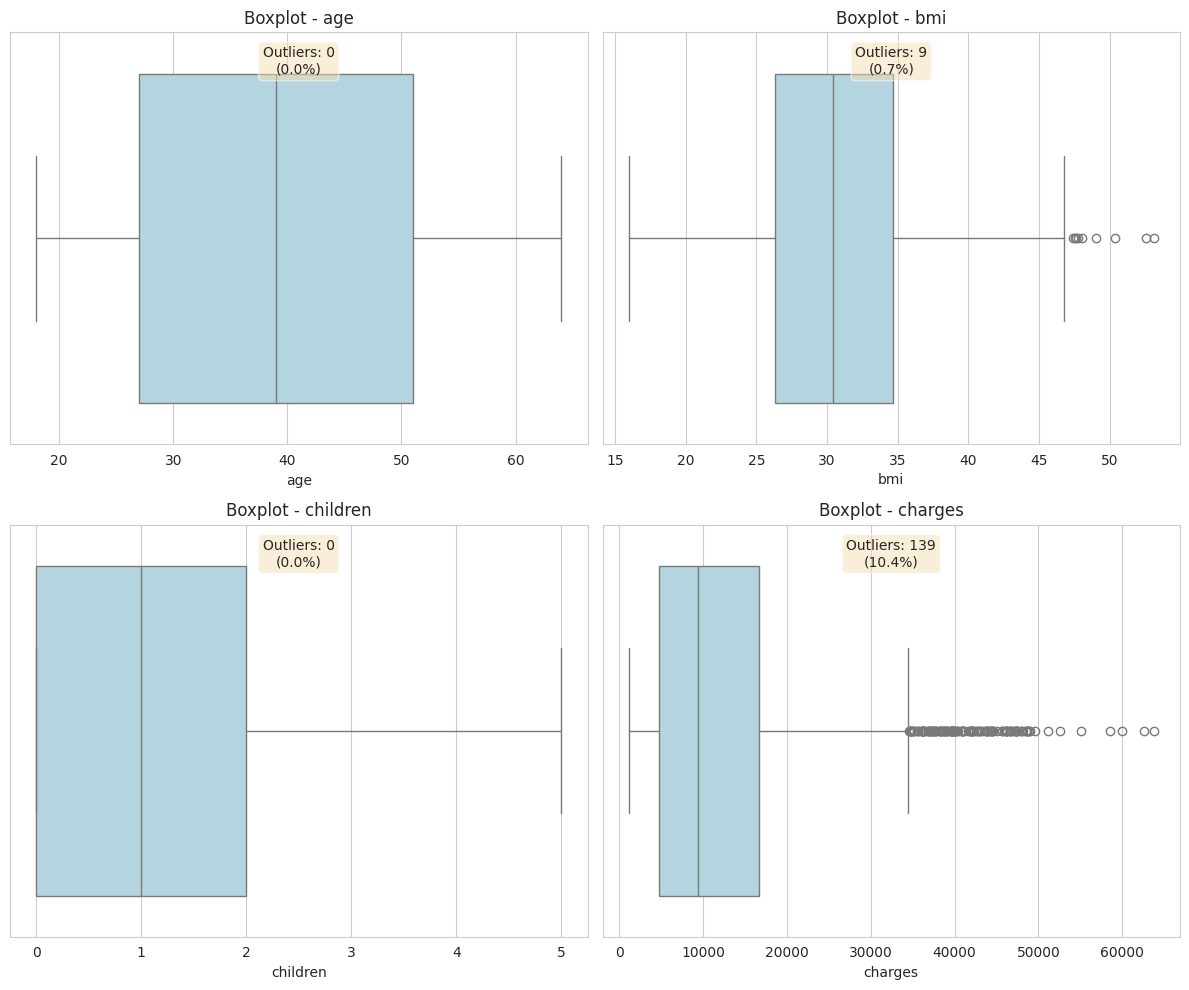


RÉSUMÉ DES OUTLIERS
------------------- 

   Variable  Nb_outliers Pourcentage     Borne_Inf     Borne_Sup
3   charges          139      10.39% -13109.150897  34489.350562
1       bmi            9       0.67%     13.700000     47.290000
0       age            0       0.00%     -9.000000     87.000000
2  children            0       0.00%     -3.000000      5.000000


In [10]:
# DÉTECTION DES OUTLIERS (IQR + BOXPLOTS)

print("\n" + "-"*70)
print("DÉTECTION DES OUTLIERS - MÉTHODE IQR")
print("-"*70)

def detect_outliers_iqr(data, column, threshold=1.5):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return outliers, lower_bound, upper_bound


#  Détecte les outliers pour toutes les colonnes numériques
def detect_all_outliers(data, numeric_columns, threshold=1.5):

    outliers_summary = []

    for col in numeric_columns:
        outliers, lower, upper = detect_outliers_iqr(data, col, threshold)

        outliers_summary.append({
            'Variable': col,
            'Nb_outliers': len(outliers),
            'Pourcentage': f"{(len(outliers)/len(data)*100):.2f}%",
            'Borne_Inf': lower,
            'Borne_Sup': upper
        })

    return pd.DataFrame(outliers_summary).sort_values('Nb_outliers', ascending=False)


# Subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, col in enumerate(numeric_features):
    if i < len(axes):

        # Boxplot
        sns.boxplot(x=df[col], ax=axes[i], color='lightblue')
        axes[i].set_title(f'Boxplot - {col}')

        # Calcul outliers
        outliers, _, _ = detect_outliers_iqr(df, col)

        # Ajouter texte
        axes[i].text(0.5, 0.9,
                     f'Outliers: {len(outliers)}\n({len(outliers)/len(df)*100:.1f}%)',
                     transform=axes[i].transAxes,
                     ha='center',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

outliers_summary = detect_all_outliers(df, numeric_features)
print("\nRÉSUMÉ DES OUTLIERS")
print("-"*19,'\n')
print(outliers_summary)



** Nettoyage et Prétraitement (Cleaning & Preprocessing)**


In [11]:
# ANALYSE DES VALEURS MANQUANTES

print("\n" + "-"*70)
print("NETTOYAGE DES VARIABLES NUMÉRIQUES ET CATÉGORIELLES")
print("-"*70)

print("\nGESTION DES MANQUANTES")
print("-"*22)

# calcul des valeurs manquantes
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) *100
missing_df = pd.DataFrame({
    'Variable': missing_data.index,
    'Nb_Manquant': missing_data.values,
    'Pourcentage': missing_percent.values
}).sort_values('Pourcentage', ascending=False)

print(missing_df)



# Stratégie de traitement des valeurs manquantes
'''
STRATÉGIE DE TRAITEMENT DES VALEURS MANQUANTES

Situation                         Méthode
1 Peu données manquantes          Suppression (lignes (dropna()) ou colonnes)
2 Données numériques              Moyenne (mean) / Médiane (median)
3 Données catégorielles           Remplir avec mode (Most frequently occurring value)
4 Absence logique (sens métier)   Remplir avec None / 0
5 Dépend du contexte              Remplir avec le médiane du quartier (df.groupby('Neighborhood')['LotFrontage'].median())
6 Dataset complexe                ML imputation (KNN Imputer, Régression, MICE(Multiple Imputation)..)
7 Info cachée / Sensible          MNAR imputation (Missing Not At Random)
'''

print("\nGESTION DES DOUBLONS")
print("-"*20)
# Détection des doublons
nb_duplicates = df.duplicated().sum()

print(f"Nombre de doublons exacts : {nb_duplicates}")

# Suppression si doublons existent
if nb_duplicates > 0:
    df = df.drop_duplicates()
    print(f"Les doublons ont été supprimés")
else:
    print("Aucun doublon détecté")

# Vérification finale
print(f"Nombre de doublons après traitement : {df.duplicated().sum()}")




----------------------------------------------------------------------
NETTOYAGE DES VARIABLES NUMÉRIQUES ET CATÉGORIELLES
----------------------------------------------------------------------

GESTION DES MANQUANTES
----------------------
   Variable  Nb_Manquant  Pourcentage
0       age            0          0.0
1       sex            0          0.0
2       bmi            0          0.0
3  children            0          0.0
4    smoker            0          0.0
5    region            0          0.0
6   charges            0          0.0

GESTION DES DOUBLONS
--------------------
Nombre de doublons exacts : 1
Les doublons ont été supprimés
Nombre de doublons après traitement : 0


In [12]:
print("\n" + "-"*70)
print("ENCODAGE DES VARIABLES CATÉGORIELLES")
print("-"*70)

# Label Encoding pour variables binaires
print("LABEL ENCODING (variables binaires):")

binary_mappings = {
    'sex': {'male': 0, 'female': 1},
    'smoker': {'no': 0, 'yes': 1}
}

# Appliquer l'encoding binaire
for col, mapping in binary_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
        print(f"   {col}: encodé en binaire (0/1)")

# One-Hot Encoding pour région
print("\nONE-HOT ENCODING:")

nominal_features = ['region']

df = pd.get_dummies(df, columns=nominal_features, drop_first=True)

print(f"   Variables encodées: {nominal_features}")
region_cols = [col for col in df.columns if col.startswith('region_')]
print(f"   Colonnes créées: {region_cols}")


# Justification du choix d'encodage
print("\n" + "-"*70)
print("Justification du choix d'encodage ")
print("-"*70)

print ("Les variables sex et smoker sont des variables catégorielles binaires qui admettent seulement 2 modalités (sex:(Homme/Femme); smoker:(Yes/No)), Ce sont des variables nominales(sans ordre)")
print("=> Label Encoding (0/1)",'\n')

print("Le variables region est un variable catégorielle  nominale avec plusieurs modalités (southwest, southeast, northwest), pour éviter l’ordre artificiel et représenter chaque région de manière indépendante.")
print("=> One-Hot Encoding",'\n')

print("\n" + "-"*70)
print(f"DIMENSIONS APÉRS ENCODAGE:")
print("-"*70)
print(f"Dimensions du dataset: {df.shape}")
print(f"Aperçu des variables après encodage: {df.columns}")




----------------------------------------------------------------------
ENCODAGE DES VARIABLES CATÉGORIELLES
----------------------------------------------------------------------
LABEL ENCODING (variables binaires):
   sex: encodé en binaire (0/1)
   smoker: encodé en binaire (0/1)

ONE-HOT ENCODING:
   Variables encodées: ['region']
   Colonnes créées: ['region_northwest', 'region_southeast', 'region_southwest']

----------------------------------------------------------------------
Justification du choix d'encodage 
----------------------------------------------------------------------
Les variables sex et smoker sont des variables catégorielles binaires qui admettent seulement 2 modalités (sex:(Homme/Femme); smoker:(Yes/No)), Ce sont des variables nominales(sans ordre)
=> Label Encoding (0/1) 

Le variables region est un variable catégorielle  nominale avec plusieurs modalités (southwest, southeast, northwest), pour éviter l’ordre artificiel et représenter chaque région de manière 


----------------------------------------------------------------------
STANDARDISATION DES VARIABLES NUMÉRIQUES
----------------------------------------------------------------------
Nombre de variables numériques à standardiser: 4
Variables: ['age', 'bmi', 'children', 'charges']

EXEMPLE DE STANDARDISATION
--------------------------
Variable: age
  Moyenne avant: 39.22
  Écart-type avant: 14.04
  Moyenne après: -6.64e-17
  Écart-type après: 1.00

VISUALISATION APRÉS/AVANT
-------------------------


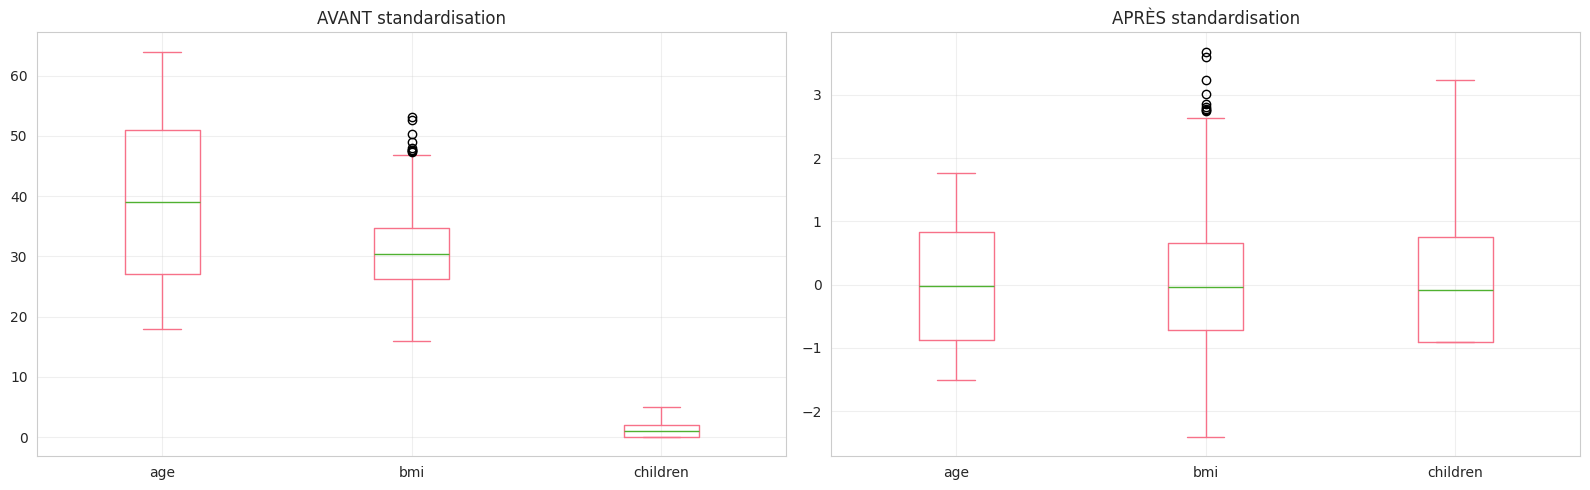

In [13]:
# STANDARDISATION DES VARIABLES NUMÉRIQUES

print("\n" + "-"*70)
print("STANDARDISATION DES VARIABLES NUMÉRIQUES")
print("-"*70)

print(f"Nombre de variables numériques à standardiser: {len(numeric_features)}")
print(f"Variables: {numeric_features}")

# copie du dataset
df_scaled = df.copy()

# Standardisation
scaler = StandardScaler()
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])

# Exemple d’une variable
print("\nEXEMPLE DE STANDARDISATION")
print("-"*26)
col = numeric_features[0]
print(f"Variable: {col}")
print(f"  Moyenne avant: {df[col].mean():.2f}")
print(f"  Écart-type avant: {df[col].std():.2f}")
print(f"  Moyenne après: {df_scaled[col].mean():.2e}")
print(f"  Écart-type après: {df_scaled[col].std():.2f}")


# Visualisation avant / après
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sample_vars = numeric_features[:3]

print("\nVISUALISATION APRÉS/AVANT")
print("-"*25)

# Avant
df[sample_vars].plot(kind='box', ax=axes[0])
axes[0].set_title('AVANT standardisation')
axes[0].grid(True, alpha=0.3)

# Après
df_scaled[sample_vars].plot(kind='box', ax=axes[1])
axes[1].set_title('APRÈS standardisation')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Séparation des features (X) et de la variable cible (y)
print("\n" + "-"*70)
print("SÉPARATION DES DONNÉES (TRAIN / TEST)")
print("-"*70, '\n')


# Préparer X et y
X = df.drop('charges', axis=1)
y = df['charges']

print(f"Dimensions de X (features): {X.shape}")
print(f"Dimensions de y (target): {y.shape}")

# Split train-test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
    random_state=42)

print(f"\nRépartition Train-Test")
print(f"  Train set: {X_train.shape[0]} observations ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]} observations ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Nombre de features: {X_train.shape[1]}")




----------------------------------------------------------------------
SÉPARATION DES DONNÉES (TRAIN / TEST)
---------------------------------------------------------------------- 

Dimensions de X (features): (1337, 8)
Dimensions de y (target): (1337,)

Répartition Train-Test
  Train set: 1069 observations (80.0%)
  Test set: 268 observations (20.0%)
  Nombre de features: 8


 **MODÉLISATION**


In [15]:
print("\n" + "-"*70)
print(" MODÉLISATION LINEAR REGRESSION - RÉGULARISATION")
print("-"*70)

# Dictionnaire pour stocker les résultats
results = {}

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """
    Entraîne et évalue un modèle
    """
    # Entraînement
    model.fit(X_train, y_train)

    # Prédictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

     # Métriques sur l'ensemble d'entraînement
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    # Adjusted R² sur l'ensemble d'entraînement
    n_train = X_train.shape[0]
    p = X_train.shape[1]
    train_adj_r2 = 1 - (1 - train_r2) * (n_train - 1) / (n_train - p - 1)

    # Métriques sur l'ensemble de test
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Adjusted R² sur l'ensemble de test
    n_test = X_test.shape[0]
    test_adj_r2 = 1 - (1 - test_r2) * (n_test - 1) / (n_test - p - 1)


    # Validation croisée
    cv_scores = cross_val_score(model, X_train, y_train, cv=5,
                                scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()

    return {
        'Model': name,
        'Train_RMSE': train_rmse,
        'Train_MAE': train_mae,
        'Train_R2': train_r2,
        'Train_Adjusted_R2': train_adj_r2,
        'Test_RMSE': test_rmse,
        'Test_MAE': test_mae,
        'Test_R2': test_r2,
        'Test_Adjusted_R2': test_adj_r2,
        'CV_RMSE': cv_rmse,
        'Predictions_Train': y_train_pred,
        'Predictions_Test': y_test_pred
    }




----------------------------------------------------------------------
 MODÉLISATION LINEAR REGRESSION - RÉGULARISATION
----------------------------------------------------------------------


In [16]:
print("\n" + "-"*70)
print("ENTRAÎNEMENT DES MODÈLES")
print("-"*70)


----------------------------------------------------------------------
ENTRAÎNEMENT DES MODÈLES
----------------------------------------------------------------------


In [22]:
# 1 LINEAR REGRESSION


print("\n1 LINEAR REGRESSION")
print("-" * 19)

lr_model = LinearRegression()
results['Linear Regression'] = evaluate_model('Linear Regression', lr_model,
                                              X_train, X_test, y_train, y_test)

print(f"  Train RMSE: {results['Linear Regression']['Train_RMSE']:.4f}")
print(f"  Test RMSE:  {results['Linear Regression']['Test_RMSE']:.4f}")
print(f"  Train MAE:  {results['Linear Regression']['Train_MAE']:.4f}")
print(f"  Test MAE:   {results['Linear Regression']['Test_MAE']:.4f}")
print(f"  Train R²:   {results['Linear Regression']['Train_R2']:.4f}")
print(f"  Test R²:    {results['Linear Regression']['Test_R2']:.4f}")
print(f"  Train Adj R²: {results['Linear Regression']['Train_Adjusted_R2']:.4f}")
print(f"  Test Adj R²:  {results['Linear Regression']['Test_Adjusted_R2']:.4f}")
print(f"  CV RMSE:    {results['Linear Regression']['CV_RMSE']:.4f}")

non_zero_coef_en = np.sum(lr_model.coef_ != 0)
print(f"  Coefficients non-nuls: {non_zero_coef_en}/{len(lr_model.coef_)}")



1 LINEAR REGRESSION
-------------------
  Train RMSE: 6081.1069
  Test RMSE:  5956.3429
  Train MAE:  4181.9015
  Test MAE:   4177.0456
  Train R²:   0.7299
  Test R²:    0.8069
  Train Adj R²: 0.7279
  Test Adj R²:  0.8010
  CV RMSE:    6113.8776
  Coefficients non-nuls: 8/8


In [24]:
# 2 RIDGE REGRESSION

print("\n2 RIDGE REGRESSION")
print("-" * 18)

ridge_model = Ridge(alpha=1.0)
results['Ridge'] = evaluate_model('Ridge', ridge_model,
                                 X_train, X_test, y_train, y_test)

print(f"  Train RMSE: {results['Ridge']['Train_RMSE']:.4f}")
print(f"  Test RMSE:  {results['Ridge']['Test_RMSE']:.4f}")
print(f"  Train MAE:  {results['Ridge']['Train_MAE']:.4f}")
print(f"  Test MAE:   {results['Ridge']['Test_MAE']:.4f}")
print(f"  Train R²:   {results['Ridge']['Train_R2']:.4f}")
print(f"  Test R²:    {results['Ridge']['Test_R2']:.4f}")
print(f"  Train Adj R²: {results['Ridge']['Train_Adjusted_R2']:.4f}")
print(f"  Test Adj R²:  {results['Ridge']['Test_Adjusted_R2']:.4f}")
print(f"  CV RMSE:    {results['Ridge']['CV_RMSE']:.4f}")

non_zero_coef_en = np.sum(ridge_model.coef_ != 0)
print(f"  Coefficients non-nuls: {non_zero_coef_en}/{len(ridge_model.coef_)}")



2 RIDGE REGRESSION
------------------
  Train RMSE: 6081.3494
  Test RMSE:  5971.3383
  Train MAE:  4190.7287
  Test MAE:   4194.0096
  Train R²:   0.7299
  Test R²:    0.8060
  Train Adj R²: 0.7278
  Test Adj R²:  0.8000
  CV RMSE:    6112.9600
  Coefficients non-nuls: 8/8


In [26]:
# 3 LASSO REGRESSION

print("\n3. LASSO REGRESSION")
print("-" * 19)

lasso_model = Lasso(alpha=0.001, max_iter=10000)
results['Lasso'] = evaluate_model('Lasso', lasso_model,
                                 X_train, X_test, y_train, y_test)

print(f"  Train RMSE: {results['Lasso']['Train_RMSE']:.4f}")
print(f"  Test RMSE:  {results['Lasso']['Test_RMSE']:.4f}")
print(f"  Train MAE:  {results['Lasso']['Train_MAE']:.4f}")
print(f"  Test MAE:   {results['Lasso']['Test_MAE']:.4f}")
print(f"  Train R²:   {results['Lasso']['Train_R2']:.4f}")
print(f"  Test R²:    {results['Lasso']['Test_R2']:.4f}")
print(f"  Train Adj R²: {results['Lasso']['Train_Adjusted_R2']:.4f}")
print(f"  Test Adj R²:  {results['Lasso']['Test_Adjusted_R2']:.4f}")
print(f"  CV RMSE:    {results['Lasso']['CV_RMSE']:.4f}")

# Nombre de coefficients non-nuls
non_zero_coef = np.sum(lasso_model.coef_ != 0)
print(f"  Coefficients non-nuls: {non_zero_coef}/{len(lasso_model.coef_)}")


3. LASSO REGRESSION
-------------------
  Train RMSE: 6081.1069
  Test RMSE:  5956.3440
  Train MAE:  4181.9019
  Test MAE:   4177.0464
  Train R²:   0.7299
  Test R²:    0.8069
  Train Adj R²: 0.7279
  Test Adj R²:  0.8010
  CV RMSE:    6113.8775
  Coefficients non-nuls: 8/8


In [ ]:
print(lasso_model.coef_)

[  248.21073293   101.53734705   318.70118308   533.00935248
 23077.75796894  -391.74482299  -838.90175744  -659.12271851]


In [28]:
# 4 ELASTIC NET

print("\n4 ELASTIC NET")
print("-" * 13)

elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
results['ElasticNet'] = evaluate_model('ElasticNet', elastic_model,
                                      X_train, X_test, y_train, y_test)

print(f"  Train RMSE: {results['ElasticNet']['Train_RMSE']:.4f}")
print(f"  Test RMSE:  {results['ElasticNet']['Test_RMSE']:.4f}")
print(f"  Train MAE:  {results['ElasticNet']['Train_MAE']:.4f}")
print(f"  Test MAE:   {results['ElasticNet']['Test_MAE']:.4f}")
print(f"  Train R²:   {results['ElasticNet']['Train_R2']:.4f}")
print(f"  Test R²:    {results['ElasticNet']['Test_R2']:.4f}")
print(f"  Train Adj R²: {results['ElasticNet']['Train_Adjusted_R2']:.4f}")
print(f"  Test Adj R²:  {results['ElasticNet']['Test_Adjusted_R2']:.4f}")
print(f"  CV RMSE:    {results['ElasticNet']['CV_RMSE']:.4f}")

non_zero_coef_en = np.sum(elastic_model.coef_ != 0)
print(f"  Coefficients non-nuls: {non_zero_coef_en}/{len(elastic_model.coef_)}")




4 ELASTIC NET
-------------
  Train RMSE: 6469.7744
  Test RMSE:  6932.6560
  Train MAE:  4660.3864
  Test MAE:   4972.9313
  Train R²:   0.6943
  Test R²:    0.7384
  Train Adj R²: 0.6920
  Test Adj R²:  0.7304
  CV RMSE:    6476.0662
  Coefficients non-nuls: 8/8


In [29]:
print("\n" + "-"*70)
print("COEFFICIENTS DES MODÈLES")
print("-"*70)

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Linear': lr_model.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_,
    'ElasticNet': elastic_model.coef_
})

print(coef_df)


----------------------------------------------------------------------
COEFFICIENTS DES MODÈLES
----------------------------------------------------------------------
            Feature        Linear         Ridge         Lasso    ElasticNet
0               age    248.210720    248.100597    248.210733    243.476325
1               sex    101.542054     91.807059    101.537347   -232.027129
2               bmi    318.701441    318.177926    318.701183    300.013855
3          children    533.009989    533.695813    533.009352    554.905825
4            smoker  23077.764593  22941.221666  23077.757969  17518.263062
5  region_northwest   -391.761455   -389.158996   -391.744823   -345.826500
6  region_southeast   -838.919616   -820.755368   -838.901757   -250.777602
7  region_southwest   -659.139752   -653.089670   -659.122719   -489.743444


In [30]:

print("\n" + "-"*70)
print("VALIDATION CROISÉE (ROBUSTESSE)")
print("-"*70)

models_dict = {
    'Linear': lr_model,
    'Ridge': ridge_model,
    'Lasso': lasso_model,
    'ElasticNet': elastic_model
}

for name, model in models_dict.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=5,
                             scoring='neg_root_mean_squared_error')

    rmse_scores = -scores

    print(f"\n{name}")
    print(f"  RMSE moyen: {rmse_scores.mean():.4f}")
    print(f"  Écart-type: {rmse_scores.std():.4f}")


----------------------------------------------------------------------
VALIDATION CROISÉE (ROBUSTESSE)
----------------------------------------------------------------------

Linear
  RMSE moyen: 6113.8776
  Écart-type: 389.5369

Ridge
  RMSE moyen: 6112.9600
  Écart-type: 393.9658

Lasso
  RMSE moyen: 6113.8775
  Écart-type: 389.5370

ElasticNet
  RMSE moyen: 6476.0662
  Écart-type: 493.7925



----------------------------------------------------------------------
COMPARAISON DES MODÈLES
----------------------------------------------------------------------

TABLEAU COMPARATIF
------------------
           Modèle  Train_RMSE   Test_RMSE   Train_MAE    Test_MAE  Train_R2  Test_R2  Train_Adj_R2  Test_Adj_R2
Linear Regression 6081.106882 5956.342894 4181.901538 4177.045561  0.729906 0.806929      0.727867     0.800965
            Ridge 6081.349393 5971.338292 4190.728722 4194.009577  0.729884 0.805955      0.727846     0.799962
            Lasso 6081.106882 5956.343980 4181.901880 4177.046409  0.729906 0.806929      0.727867     0.800965
       ElasticNet 6469.774381 6932.656011 4660.386382 4972.931326  0.694277 0.738448      0.691970     0.730369 

VISUALISATION DE LA COMPARAISON
-------------------------------


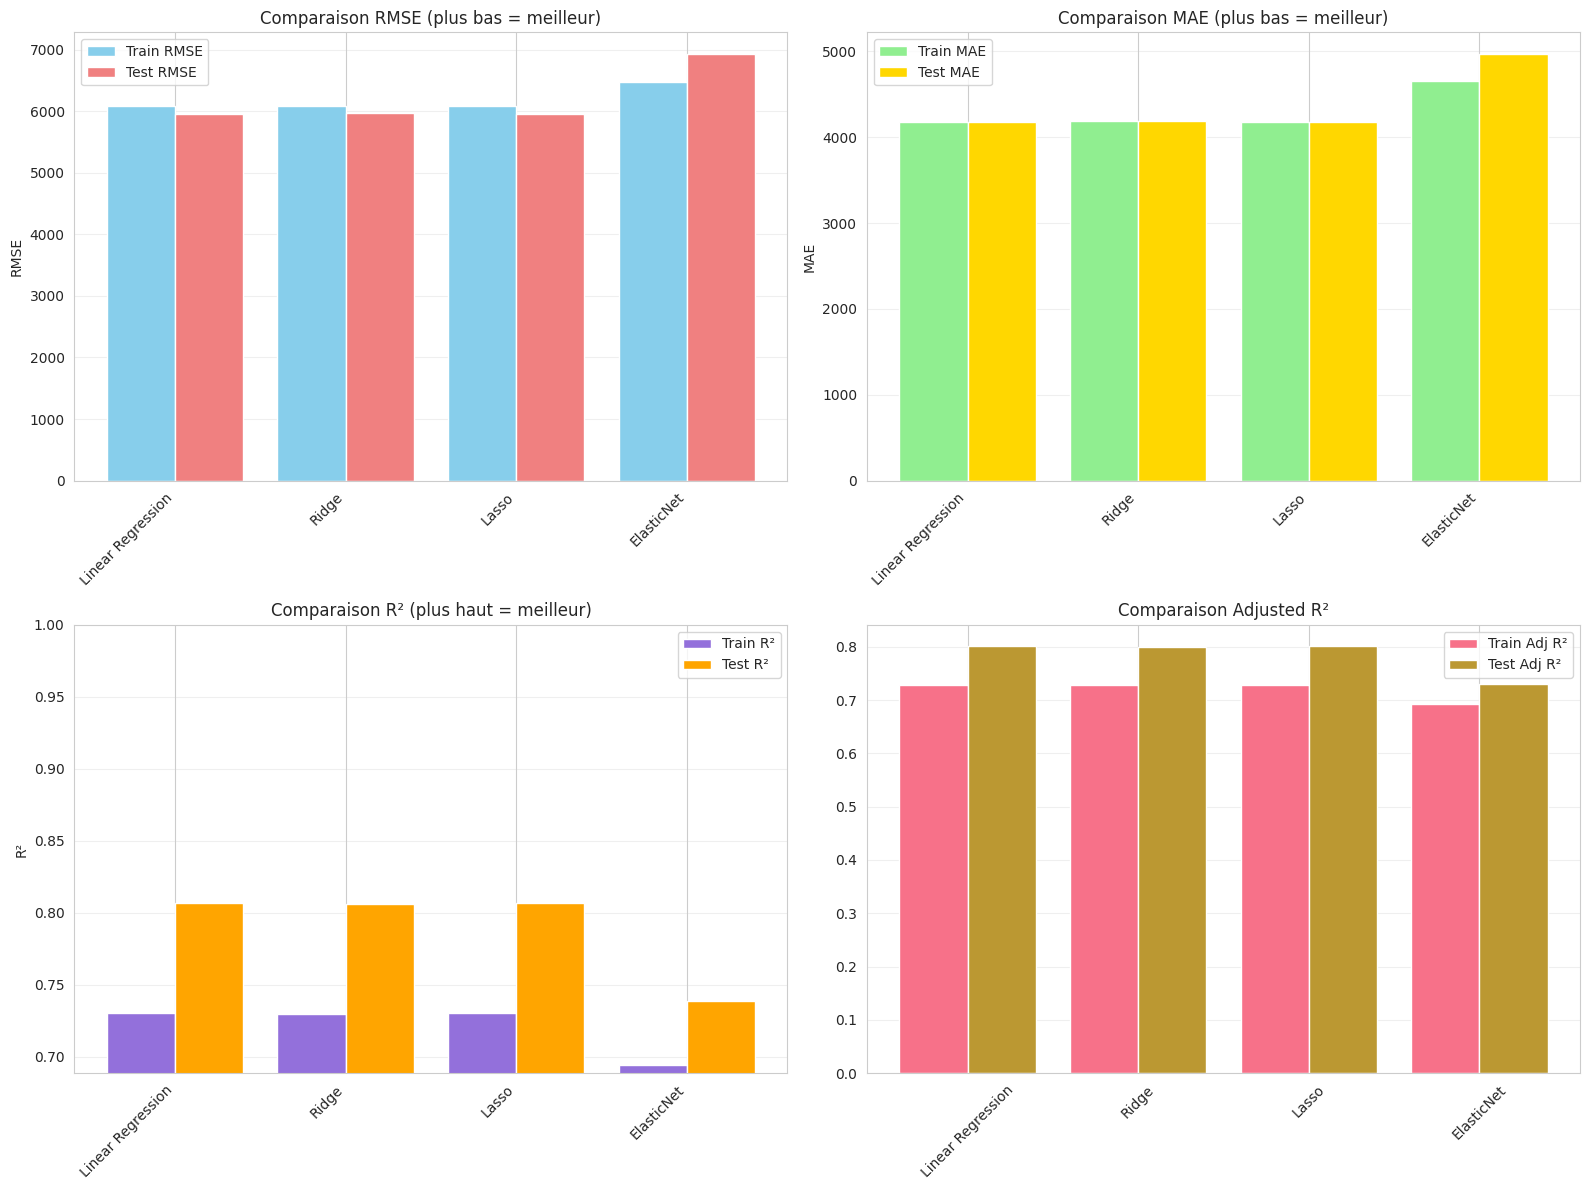

In [31]:
# COMPARAISON DES MODÈLES

print("\n" + "-"*70)
print("COMPARAISON DES MODÈLES")
print("-"*70)


comparison_df = pd.DataFrame({
    'Modèle': list(results.keys()),
    'Train_RMSE': [results[m]['Train_RMSE'] for m in results],
    'Test_RMSE': [results[m]['Test_RMSE'] for m in results],
    'Train_MAE': [results[m]['Train_MAE'] for m in results],
    'Test_MAE': [results[m]['Test_MAE'] for m in results],
    'Train_R2': [results[m]['Train_R2'] for m in results],
    'Test_R2': [results[m]['Test_R2'] for m in results],
    'Train_Adj_R2': [results[m]['Train_Adjusted_R2'] for m in results],
    'Test_Adj_R2': [results[m]['Test_Adjusted_R2'] for m in results],

})

print("\nTABLEAU COMPARATIF")
print("-"*18)

print(comparison_df.to_string(index=False),'\n')

# Visualisation de la comparaison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models = list(results.keys())
x_pos = np.arange(len(models))


# RMSE Comparison
axes[0, 0].bar(x_pos - 0.2, comparison_df['Train_RMSE'], 0.4,
              label='Train RMSE', color='skyblue')
axes[0, 0].bar(x_pos + 0.2, comparison_df['Test_RMSE'], 0.4,
              label='Test RMSE', color='lightcoral')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(models, rotation=45, ha='right')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].set_title('Comparaison RMSE (plus bas = meilleur)')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# MAE Comparison
axes[0, 1].bar(x_pos - 0.2, comparison_df['Train_MAE'], 0.4,
              label='Train MAE', color='lightgreen')
axes[0, 1].bar(x_pos + 0.2, comparison_df['Test_MAE'], 0.4,
              label='Test MAE', color='gold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(models, rotation=45, ha='right')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_title('Comparaison MAE (plus bas = meilleur)')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# R² Comparison
axes[1, 0].bar(x_pos - 0.2, comparison_df['Train_R2'], 0.4,
              label='Train R²', color='mediumpurple')
axes[1, 0].bar(x_pos + 0.2, comparison_df['Test_R2'], 0.4,
              label='Test R²', color='orange')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(models, rotation=45, ha='right')
axes[1, 0].set_ylabel('R²')
axes[1, 0].set_title('Comparaison R² (plus haut = meilleur)')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_ylim([min(comparison_df['Test_R2'])-0.05, 1.0])

# Adjusted R² comparaison
axes[1, 1].bar(x_pos - 0.2, comparison_df['Train_Adj_R2'], 0.4,
              label='Train Adj R²')
axes[1, 1].bar(x_pos + 0.2, comparison_df['Test_Adj_R2'], 0.4,
              label='Test Adj R²')
axes[1, 1].set_title('Comparaison Adjusted R²')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(models, rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)


print("VISUALISATION DE LA COMPARAISON")
print("-"*31)


plt.tight_layout()
plt.show()






----------------------------------------------------------------------
DISTRIBUTION DES RÉSIDUS
----------------------------------------------------------------------


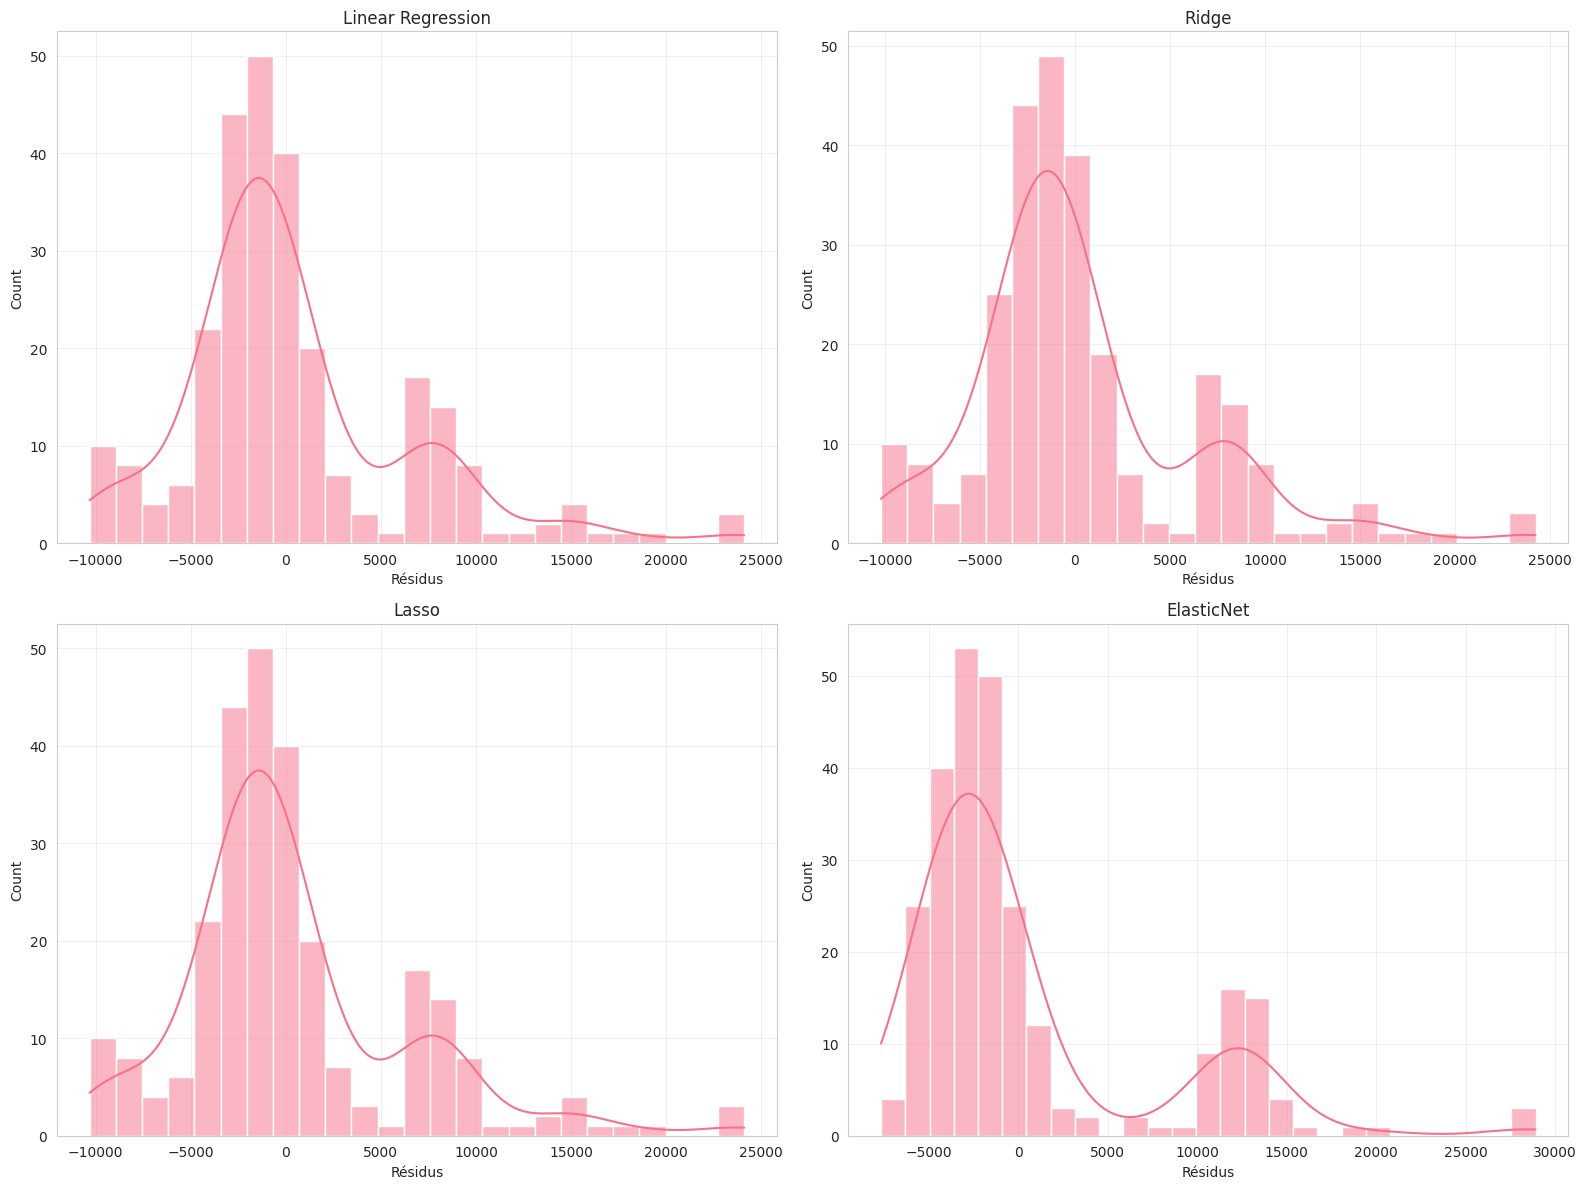

In [32]:
# Distribution des résidus pour chaque modèle
print("\n" + "-"*70)
print("DISTRIBUTION DES RÉSIDUS")
print("-"*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

models = list(results.keys())

for i, model_name in enumerate(models):
    y_pred = results[model_name]['Predictions_Test']
    residuals = y_test - y_pred

    sns.histplot(residuals, kde=True, ax=axes[i])

    axes[i].set_title(f"{model_name}")
    axes[i].set_xlabel("Résidus")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


----------------------------------------------------------------------
PRÉDICTIONS VS VALEURS RÉELLES
----------------------------------------------------------------------


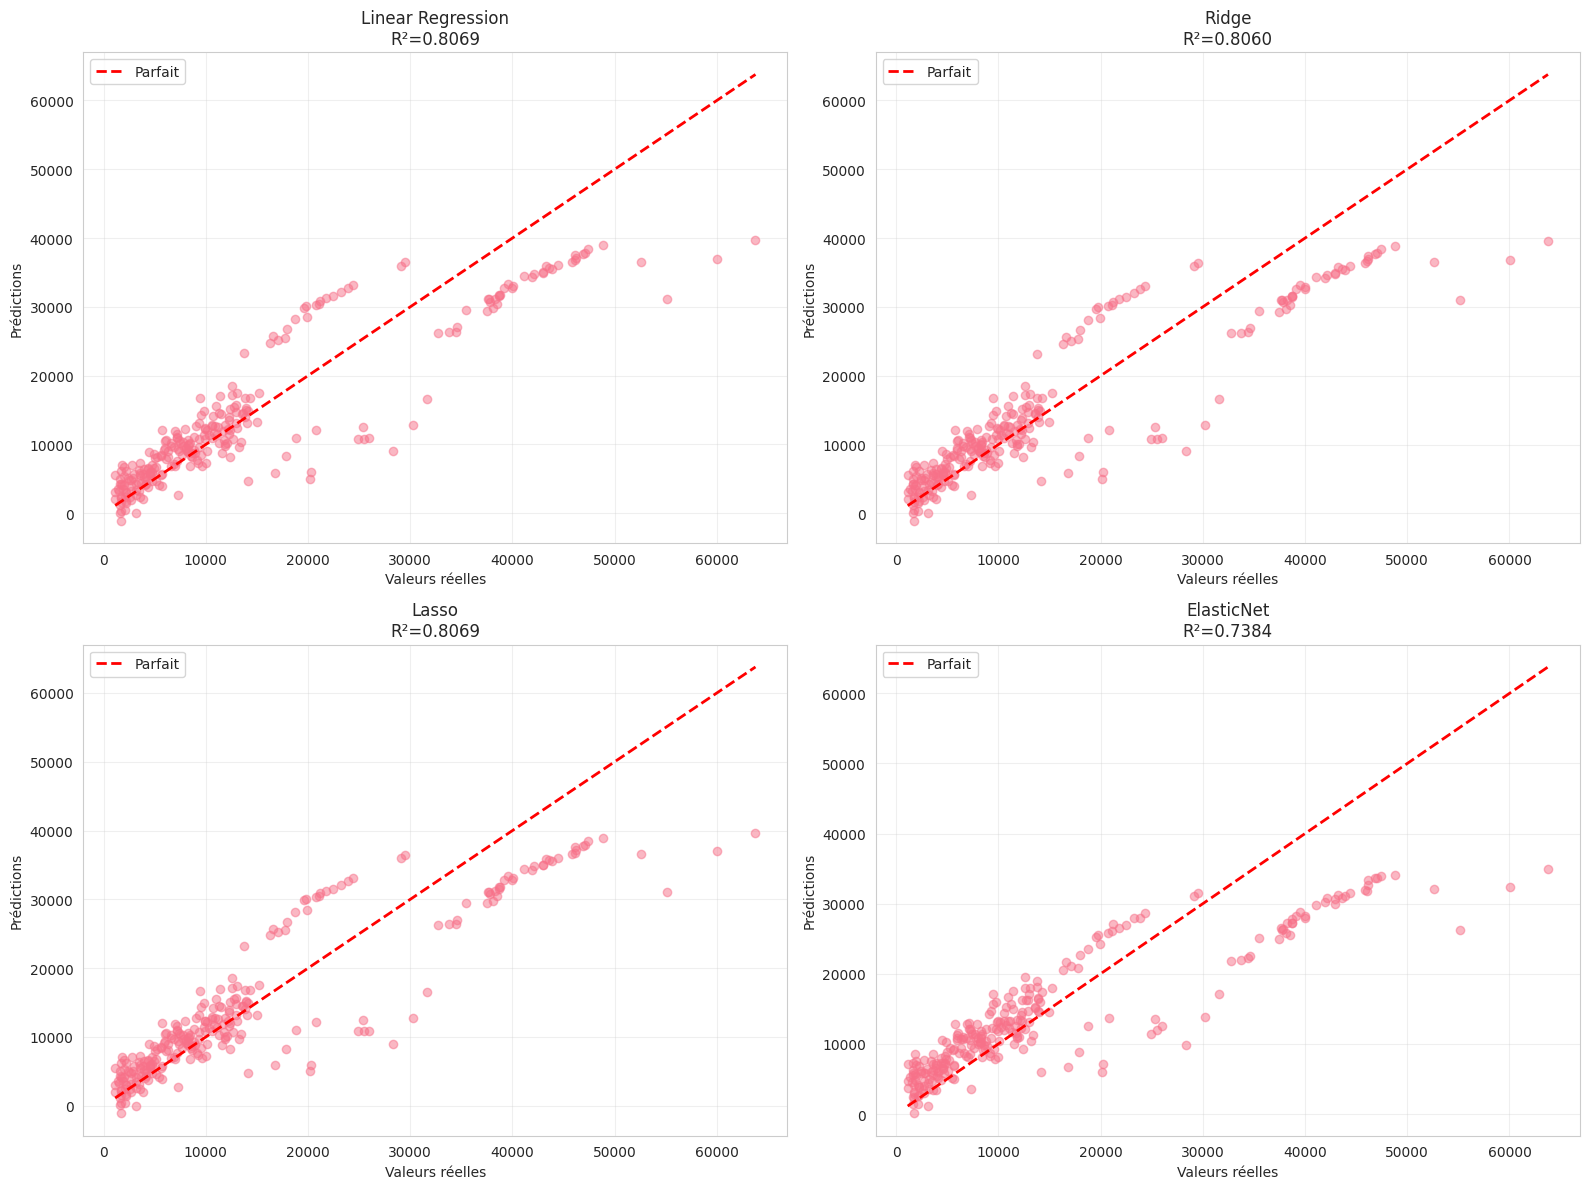

In [33]:
# Prédictions vs Valeurs réelles

print("\n" + "-"*70)
print("PRÉDICTIONS VS VALEURS RÉELLES")
print("-"*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(models):
    y_pred = results[model_name]['Predictions_Test']

    axes[i].scatter(y_test, y_pred, alpha=0.5)
    axes[i].plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()],
                'r--', lw=2, label='Parfait')
    axes[i].set_xlabel('Valeurs réelles')
    axes[i].set_ylabel('Prédictions')
    axes[i].set_title(f'{model_name}\nR²={results[model_name]["Test_R2"]:.4f}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Les résultats montrent que les modèles **Linear Regression** et **Lasso** présentent des performances identiques en termes de RMSE, MAE et R². Cependant,le modèle Lasso n'a pas permis de réduire le nombre de variables, car aucun coefficient n'a été annulé. Ainsi, il n'apporte pas de gain en termes de simplification du modèle.

Le modèle **Ridge** présente des performances légèrement inférieures, tandis que le modèle **ElasticNet** affiche des résultats nettement moins bons.

=> Le modèle de régression linéaire (Linear Regression) est retenu comme le meilleur modèle.


In [34]:
X_train = X_train.astype(float)
y_train = y_train.astype(float)

print(X_train.dtypes)

age                 float64
sex                 float64
bmi                 float64
children            float64
smoker              float64
region_northwest    float64
region_southeast    float64
region_southwest    float64
dtype: object


In [35]:
# SÉLECTION DE VARIABLES - BACKWARD ELIMINATION

print("\n" + "-"*70)
print("SÉLECTION DE VARIABLES PAR BACKWARD ELIMINATION")
print("-"*70)


print("\nBACKWARD ELIMINATION")
print("-"*20)

X_train = X_train.astype(float)
y_train = y_train.astype(float)

def backward_elimination(X, y, sl=0.05):
    features = list(X.columns)

    while True:
        # ajouter une constante
        X_const = sm.add_constant(X[features])

        # ajuster le modèle
        model = sm.OLS(y, X_const).fit()

        # Trouver la variable avec la p-value la plus élevée
        p_values = model.pvalues.iloc[1:]  # exclure constante
        max_p = p_values.max()

        if max_p > sl:
            worst_feature = p_values.idxmax()
            print(f"Remove: {worst_feature} (p_value={max_p:.4f})")
            features.remove(worst_feature)
        else:
            break

    return features

# Appliquer backward elimination
selected_features = backward_elimination(X_train, y_train)

print("\nFeatures sélectionnées:")
print(selected_features)

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("\nNOUVEAUX DATASETS APRÈS SÉLECTION")
print("-"*33)


print(f"\nNouvelles dimensions:")
print(f"  X_train: {X_train_selected.shape}")
print(f"  X_test: {X_test_selected.shape}")



----------------------------------------------------------------------
SÉLECTION DE VARIABLES PAR BACKWARD ELIMINATION
----------------------------------------------------------------------

BACKWARD ELIMINATION
--------------------
Remove: sex (p_value=0.7871)
Remove: region_northwest (p_value=0.4656)
Remove: region_southwest (p_value=0.3264)
Remove: region_southeast (p_value=0.2859)

Features sélectionnées:
['age', 'bmi', 'children', 'smoker']

NOUVEAUX DATASETS APRÈS SÉLECTION
---------------------------------

Nouvelles dimensions:
  X_train: (1069, 4)
  X_test: (268, 4)


In [37]:
# MODÉLISATION AVEC VARIABLES SÉLECTIONNÉES
from sklearn.feature_selection import RFE

print("\n" + "-"*70)
print("RFE - SELECTION DE FEATURES")
print("-"*70)

model = LinearRegression()

rfe = RFE(estimator=model, n_features_to_select=5)
rfe.fit(X_train, y_train)

selected_rfe = X_train.columns[rfe.support_]

print("Features sélectionnées par RFE:")
print(list(selected_rfe))

print(pd.DataFrame({
    'Feature': X_train.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}))


----------------------------------------------------------------------
RFE - SELECTION DE FEATURES
----------------------------------------------------------------------
Features sélectionnées par RFE:
['children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
            Feature  Selected  Ranking
0               age     False        3
1               sex     False        4
2               bmi     False        2
3          children      True        1
4            smoker      True        1
5  region_northwest      True        1
6  region_southeast      True        1
7  region_southwest      True        1


La méthode **RFE** a permis de sélectionner un sous-ensemble de variables. Cependant, certaines variables importantes telles que "age" et "bmi" ont été exclues, ce qui n'est pas cohérent avec les analyses précédentes. Cela s'explique par le fait que le nombre de variables sélectionnées a été fixé arbitrairement, ce qui peut conduire à une perte d'information. Ainsi, les résultats de RFE doivent être interprétés avec précaution.

In [38]:
print("\n" + "-"*70)
print("FEATURE SELECTION - LASSO")
print("-"*70)

coef = pd.Series(lasso_model.coef_, index=X_train.columns)

selected_lasso = coef[coef != 0].index

print("Features gardées par Lasso:")
print(list(selected_lasso))

print("\nFeatures supprimées:")
print(list(coef[coef == 0].index))

# Lasso met certains coefficients à 0


----------------------------------------------------------------------
FEATURE SELECTION - LASSO
----------------------------------------------------------------------
Features gardées par Lasso:
['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']

Features supprimées:
[]


**Backward Elimination** est retenue car elle sélectionne uniquement les variables statistiquement significatives, contrairement à **Lasso** qui ne réduit pas le modèle et à **RFE** qui supprime des variables importantes.

In [39]:
# MODÉLISATION AVEC VARIABLES SÉLECTIONNÉES

print("\n" + "-"*70)
print("MODÉLISATION AVEC VARIABLES SÉLECTIONNÉES")
print("-"*70)

# Dictionnaire pour stocker les résultats avec sélection
results_selected = {}




----------------------------------------------------------------------
MODÉLISATION AVEC VARIABLES SÉLECTIONNÉES
----------------------------------------------------------------------


In [50]:
# 1 LINEAR REGRESSION (avec sélection)

print("\n1 LINEAR REGRESSION (Variables sélectionnées)")
print("-" * 45)

lr_model_selected = LinearRegression()
results_selected['Linear Regression'] = evaluate_model(
    'Linear Regression', lr_model_selected,
    X_train_selected, X_test_selected, y_train, y_test
)

print(f"  Train RMSE: {results_selected['Linear Regression']['Train_RMSE']:.4f}")
print(f"  Test RMSE:  {results_selected['Linear Regression']['Test_RMSE']:.4f}")
print(f"  Train MAE:  {results_selected['Linear Regression']['Train_MAE']:.4f}")
print(f"  Test MAE:   {results_selected['Linear Regression']['Test_MAE']:.4f}")
print(f"  Train R²:   {results_selected['Linear Regression']['Train_R2']:.4f}")
print(f"  Test R²:    {results_selected['Linear Regression']['Test_R2']:.4f}")
print(f"  Train Adj R²: {results['Linear Regression']['Train_Adjusted_R2']:.4f}")
print(f"  Test Adj R²:  {results['Linear Regression']['Test_Adjusted_R2']:.4f}")
print(f"  CV RMSE:    {results_selected['Linear Regression']['CV_RMSE']:.4f}")




1 LINEAR REGRESSION (Variables sélectionnées)
---------------------------------------------
  Train RMSE: 6088.8665
  Test RMSE:  5992.8751
  Train MAE:  4187.5235
  Test MAE:   4198.5926
  Train R²:   0.7292
  Test R²:    0.8046
  Train Adj R²: 0.7279
  Test Adj R²:  0.8010
  CV RMSE:    6111.0297


In [51]:
 # 2 LASSO REGRESSION (avec sélection)

print("\n2 LASSO REGRESSION (Variables sélectionnées)")
print("-" * 44)

lasso_model_selected = Lasso(alpha=0.001, max_iter=10000, random_state=42)
results_selected['Lasso'] = evaluate_model(
    'Lasso', lasso_model_selected,
    X_train_selected, X_test_selected, y_train, y_test
)

print(f"  Train RMSE: {results_selected['Lasso']['Train_RMSE']:.4f}")
print(f"  Test RMSE:  {results_selected['Lasso']['Test_RMSE']:.4f}")
print(f"  Train MAE:  {results_selected['Lasso']['Train_MAE']:.4f}")
print(f"  Test MAE:   {results_selected['Lasso']['Test_MAE']:.4f}")
print(f"  Train R²:   {results_selected['Lasso']['Train_R2']:.4f}")
print(f"  Test R²:    {results_selected['Lasso']['Test_R2']:.4f}")
print(f"  Train Adj R²: {results['Lasso']['Train_Adjusted_R2']:.4f}")
print(f"  Test Adj R²:  {results['Lasso']['Test_Adjusted_R2']:.4f}")
print(f"  CV RMSE:    {results_selected['Lasso']['CV_RMSE']:.4f}")



2 LASSO REGRESSION (Variables sélectionnées)
--------------------------------------------
  Train RMSE: 6088.8665
  Test RMSE:  5992.8757
  Train MAE:  4187.5239
  Test MAE:   4198.5933
  Train R²:   0.7292
  Test R²:    0.8046
  Train Adj R²: 0.7279
  Test Adj R²:  0.8010
  CV RMSE:    6111.0297


In [52]:
# 3 RIDGE REGRESSION (avec sélection)

print("\n3 RIDGE REGRESSION (Variables sélectionnées)")
print("-" * 43)

ridge_model_selected = Ridge(alpha=10, random_state=42)
results_selected['Ridge'] = evaluate_model(
    'Ridge', ridge_model_selected,
    X_train_selected, X_test_selected, y_train, y_test
)

print(f"  Train RMSE: {results_selected['Ridge']['Train_RMSE']:.4f}")
print(f"  Test RMSE:  {results_selected['Ridge']['Test_RMSE']:.4f}")
print(f"  Train MAE:  {results_selected['Ridge']['Train_MAE']:.4f}")
print(f"  Test MAE:   {results_selected['Ridge']['Test_MAE']:.4f}")
print(f"  Train R²:   {results_selected['Ridge']['Train_R2']:.4f}")
print(f"  Test R²:    {results_selected['Ridge']['Test_R2']:.4f}")
print(f"  Train Adj R²: {results['Ridge']['Train_Adjusted_R2']:.4f}")
print(f"  Test Adj R²:  {results['Ridge']['Test_Adjusted_R2']:.4f}")
print(f"  CV RMSE:    {results_selected['Ridge']['CV_RMSE']:.4f}")




3 RIDGE REGRESSION (Variables sélectionnées)
-------------------------------------------
  Train RMSE: 6110.1374
  Test RMSE:  6149.5159
  Train MAE:  4275.5580
  Test MAE:   4363.2584
  Train R²:   0.7273
  Test R²:    0.7942
  Train Adj R²: 0.7278
  Test Adj R²:  0.8000
  CV RMSE:    6135.3131


In [59]:
# 4 ELASTIC NET (avec sélection)

print("\n4 ELASTIC NET (Variables sélectionnées)")
print("-" * 39)

elasticnet_model_selected = ElasticNet(alpha=0.001, l1_ratio=0.5,
                            max_iter=10000, random_state=42)
results_selected['ElasticNet'] = evaluate_model(
    'ElasticNet', elasticnet_model_selected,
    X_train_selected, X_test_selected, y_train, y_test
)

print(f"  Train RMSE: {results_selected['ElasticNet']['Train_RMSE']:.4f}")
print(f"  Test RMSE:  {results_selected['ElasticNet']['Test_RMSE']:.4f}")
print(f"  Train MAE:  {results_selected['ElasticNet']['Train_MAE']:.4f}")
print(f"  Test MAE:   {results_selected['ElasticNet']['Test_MAE']:.4f}")
print(f"  Train R²:   {results_selected['ElasticNet']['Train_R2']:.4f}")
print(f"  Test R²:    {results_selected['ElasticNet']['Test_R2']:.4f}")
print(f"  Train Adj R²: {results['ElasticNet']['Train_Adjusted_R2']:.4f}")
print(f"  Test Adj R²:  {results['ElasticNet']['Test_Adjusted_R2']:.4f}")
print(f"  CV RMSE:    {results_selected['ElasticNet']['CV_RMSE']:.4f}")




4 ELASTIC NET (Variables sélectionnées)
---------------------------------------
  Train RMSE: 6088.9343
  Test RMSE:  6000.5553
  Train MAE:  4192.1567
  Test MAE:   4207.5970
  Train R²:   0.7292
  Test R²:    0.8041
  Train Adj R²: 0.6920
  Test Adj R²:  0.7304
  CV RMSE:    6110.7031



----------------------------------------------------------------------
COMPARAISON FINALE: TOUTES VARIABLES VS VARIABLES SÉLECTIONNÉES
----------------------------------------------------------------------

TABLEAU COMPARATIF FINAL
------------------------
           Modèle    All_RMSE     All_MAE   All_R2  All_Adj_R2    Sel_RMSE     Sel_MAE   Sel_R2  Sel_Adj_R2  Amélioration_RMSE  Amélioration_MAE  Amélioration_R2  Amélioration_Adj_R2
Linear Regression 5956.342894 4177.045561 0.806929    0.800965 5992.875060 4198.592612 0.804553    0.801581         -36.532165        -21.547051        -0.002376             0.000615
            Ridge 5971.338292 4194.009577 0.805955    0.799962 5992.875680 4198.593265 0.804553    0.801580         -21.537388         -4.583688        -0.001402             0.001619
            Lasso 5956.343980 4177.046409 0.806929    0.800965 6149.515892 4363.258364 0.794202    0.791072        -193.171912       -186.211955        -0.012726            -0.009893
       Ela

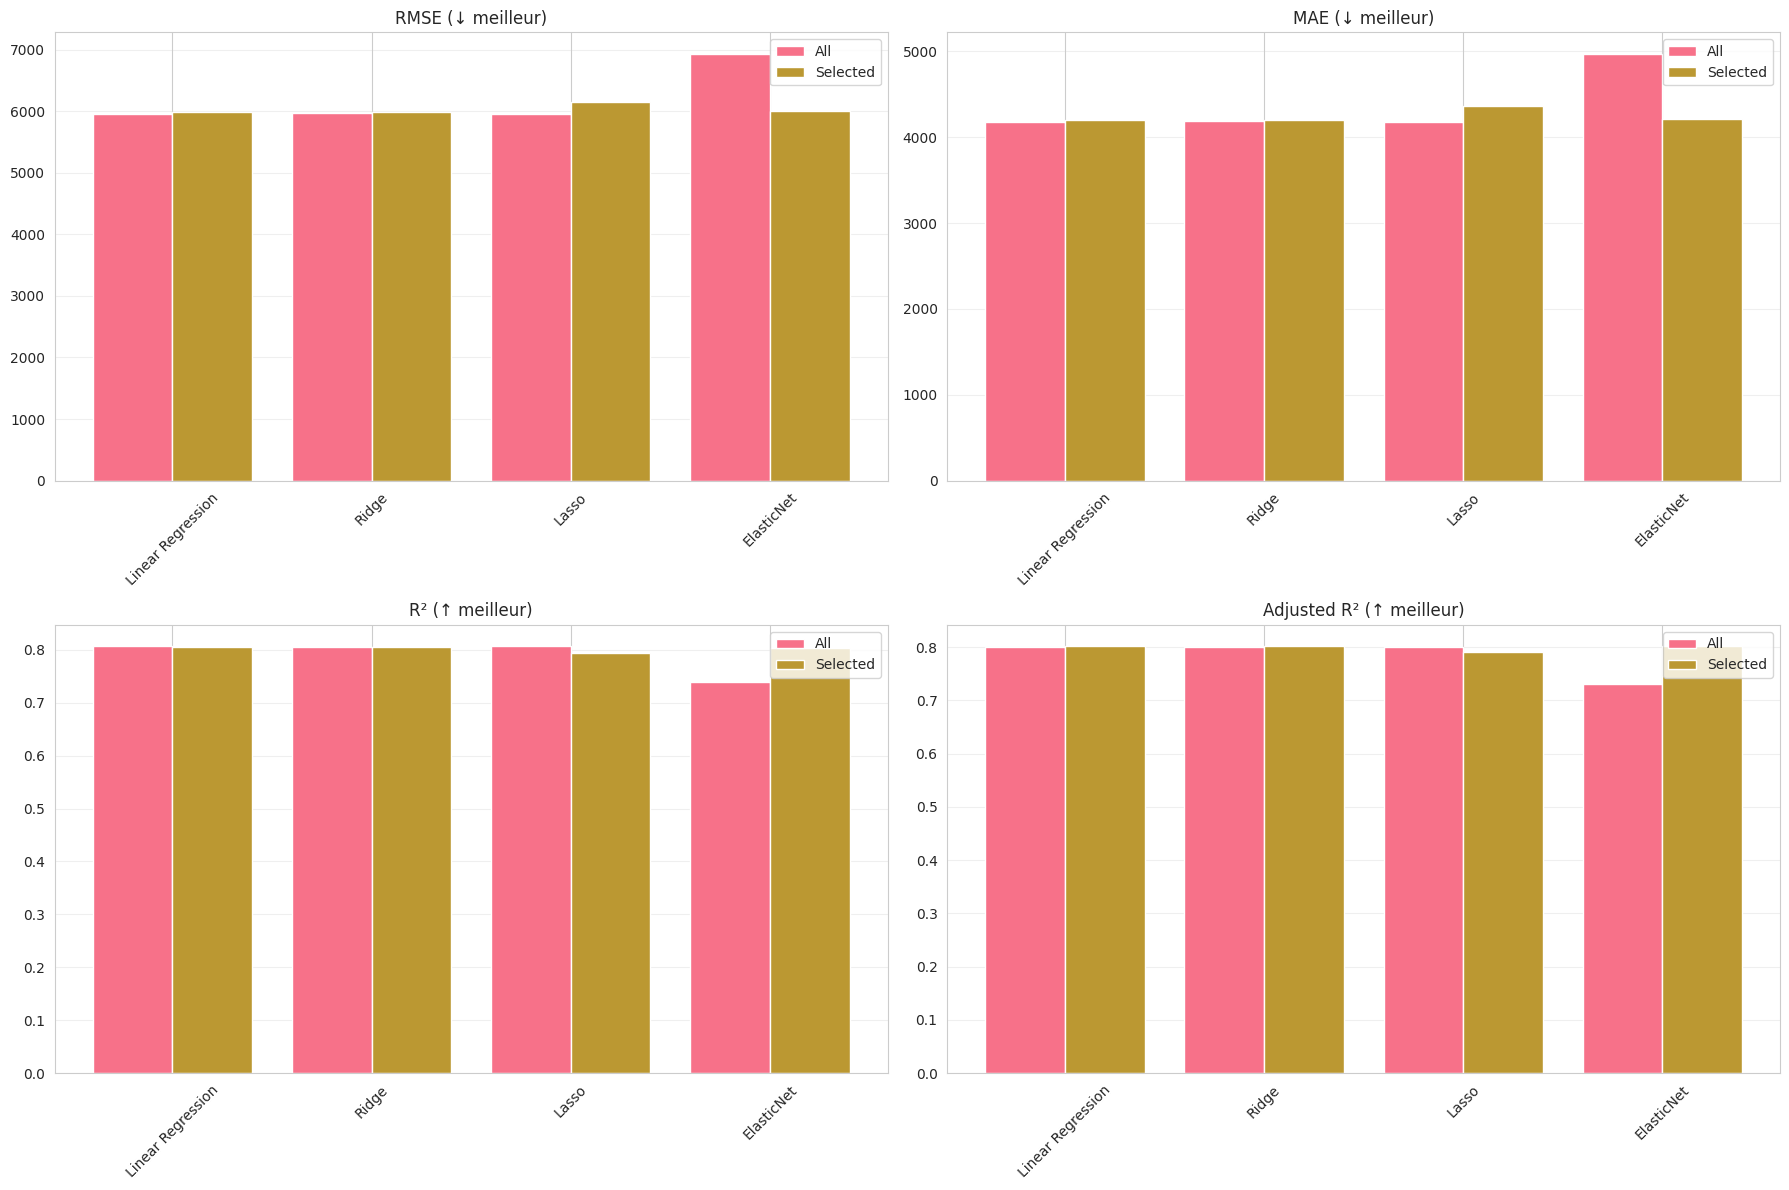

In [70]:
# COMPARAISON FINALE: AVEC ET SANS SÉLECTION

print("\n" + "-"*70)
print("COMPARAISON FINALE: TOUTES VARIABLES VS VARIABLES SÉLECTIONNÉES")
print("-"*70)

# DataFrame complet
comparison_final = pd.DataFrame({
    'Modèle': list(results.keys()),

    # ALL FEATURES
    'All_RMSE': [results[m]['Test_RMSE'] for m in results],
    'All_MAE': [results[m]['Test_MAE'] for m in results],
    'All_R2': [results[m]['Test_R2'] for m in results],
    'All_Adj_R2': [results[m]['Test_Adjusted_R2'] for m in results],

    # SELECTED FEATURES
    'Sel_RMSE': [results_selected[m]['Test_RMSE'] for m in results_selected],
    'Sel_MAE': [results_selected[m]['Test_MAE'] for m in results_selected],
    'Sel_R2': [results_selected[m]['Test_R2'] for m in results_selected],
    'Sel_Adj_R2': [results_selected[m]['Test_Adjusted_R2'] for m in results_selected],
})

# Améliorations
comparison_final['Amélioration_RMSE'] = comparison_final['All_RMSE'] - comparison_final['Sel_RMSE']
comparison_final['Amélioration_MAE'] = comparison_final['All_MAE'] - comparison_final['Sel_MAE']
comparison_final['Amélioration_R2'] = comparison_final['Sel_R2'] - comparison_final['All_R2']
comparison_final['Amélioration_Adj_R2'] = comparison_final['Sel_Adj_R2'] - comparison_final['All_Adj_R2']

print("\nTABLEAU COMPARATIF FINAL")
print("-"*24)
print(comparison_final.to_string(index=False))


fig, axes = plt.subplots(2, 2, figsize=(18, 12))

models = comparison_final['Modèle']
x = np.arange(len(models))

# RMSE comparaison
axes[0,0].bar(x - 0.2, comparison_final['All_RMSE'], 0.4, label='All')
axes[0,0].bar(x + 0.2, comparison_final['Sel_RMSE'], 0.4, label='Selected')
axes[0,0].set_title("RMSE (↓ meilleur)")
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(models, rotation=45)
axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)

# MAE comparaison
axes[0,1].bar(x - 0.2, comparison_final['All_MAE'], 0.4, label='All')
axes[0,1].bar(x + 0.2, comparison_final['Sel_MAE'], 0.4, label='Selected')
axes[0,1].set_title("MAE (↓ meilleur)")
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(models, rotation=45)
axes[0,1].legend()
axes[0,1].grid(axis='y', alpha=0.3)

# R² comparaison
axes[1,0].bar(x - 0.2, comparison_final['All_R2'], 0.4, label='All')
axes[1,0].bar(x + 0.2, comparison_final['Sel_R2'], 0.4, label='Selected')
axes[1,0].set_title("R² (↑ meilleur)")
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(models, rotation=45)
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)

# Adjusted R² comparaison
axes[1,1].bar(x - 0.2, comparison_final['All_Adj_R2'], 0.4, label='All')
axes[1,1].bar(x + 0.2, comparison_final['Sel_Adj_R2'], 0.4, label='Selected')
axes[1,1].set_title("Adjusted R² (↑ meilleur)")
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(models, rotation=45)
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)

print("\nVISUALISATION DE LA COMPARAISON FINALE ")
print("-"*38)

plt.tight_layout()
plt.show()

**RMSE/MAE** : positif => amélioration / négatif => dégradation

**R² / Adjusted R²** : positif => amélioration / négatif => dégradation

Pour **Linear Regression** et **Ridge**, les performances restent globalement stables malgré la réduction des variables (4 au lieu de 8), avec une légère amélioration de l'Adjusted R². Cela montre que les variables supprimées n'étaient pas essentielles.

Le modèle **Lasso** présente une dégradation des performances, indiquant qu'il est sensible à la réduction des variables dans ce cas.

Le modèle **ElasticNet** bénéficie fortement de la sélection de variables, avec une amélioration significative de toutes les métriques, ce qui suggère qu'il bénéficiait de la suppression du bruit.


# Meilleur modèle identifié
Le modèle **Linear Regression** a été identifié comme le meilleur modèle, car il offre un bon compromis entre performance et interprétabilité, avec des résultats très proches de Ridge et Lasso.

# Features les plus importantes pour la prédiction
Les variables les plus importantes pour la prédiction des charges sont :
*   Smoker (impact très élevé)
*   bmi
*   children
*   age

# Observations clés
Le statut **smoker** est de loin le facteur le plus influent sur les charges médicales, avec un impact très significatif.

Les **individus fumeurs** présentent des coûts nettement plus élevés, ce qui est cohérent avec les risques accrus pour la santé.

Les variables **bmi** et** age **contribuent également de manière importante, reflétant l'impact des facteurs physiologiques sur les dépenses médicales.

# Limites du projet
Dataset relativement limitée, Certaines variables potentiellement importantes ne sont pas présentes (ex: alimentation, historique médical, activité physique..)

Les modèles utilisés reposent sur une hypothèse de linéarité(chaque variable a un effet simple, constant et indépendant),
supposant que les relations sont des droites, alors qu'en réalité elles peuvent être plus complexes.

# Perspectives d'amélioration
Utiliser des modèles non linéaires tels que Decision Tree, Random Forest ou XGBoost pour capturer des relations plus complexes.

Appliquer du feature engineering (interactions entre variables, transformations polynomiales).


Collecter davantage de données pour améliorer la robustesse et la performance du modèle.

# Conclusion finale
La sélection de variables a permis de simplifier le modèle sans perte significative de performance. Le statut de fumeur apparaît comme le facteur déterminant dans la prédiction des charges, et des approches plus avancées pourraient encore améliorer les résultats.







